# Trivago RecSys Challenge 2019 — Phân tích khám phá dữ liệu

Notebook EDA rút gọn theo hướng dẫn; mỗi chủ đề có phần tính toán và biểu đồ trong cùng code cell.

## 1. Môi trường

Thiết lập thư viện và đường dẫn.

In [2]:
# Cell 1: Cấu hình
# Input/phạm vi: môi trường/đường dẫn
# Output: hàm và thư viện
# Cell 1: Cấu hình thư viện, đường dẫn, hàm phụ trợ và hệ màu
# Input/phạm vi: môi trường Python và các đường dẫn trong ROOT; chưa đọc dữ liệu
# Output: khai báo phiên bản, seed, chunksize, hàm parse, hash và palette; chưa tạo bảng hay hình
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path
import hashlib
import platform
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline
from IPython.display import Markdown, display

ROOT = Path(r'D:\VSF\Data\Tourism\Trivago_RecSys_Challenge_2019')
RAW = ROOT / 'raw'
FILES = ['train.csv', 'test.csv', 'item_metadata.csv', 'submission_popular.csv']
CHUNKSIZE = 200_000
SEED = 42
CLICKOUT = 'clickout item'
EXPECTED_EVENTS = [
    'user_id', 'session_id', 'timestamp', 'step', 'action_type', 'reference',
    'platform', 'city', 'device', 'current_filters', 'impressions', 'prices',
]
NOTEBOOK_VERSION = '1.0'

random.seed(SEED)
np.random.seed(SEED)
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 40)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')

# Dùng mapping màu cố định để nhóm dữ liệu nhất quán giữa các hình.
COLORS = {
    'primary': '#0072B2',
    'secondary': '#56B4E9',
    'positive': '#009E73',
    'warning': '#E69F00',
    'negative': '#D55E00',
    'accent': '#CC79A7',
    'neutral': '#94A3B8',
}
SPLIT_COLORS = {
    'train': COLORS['primary'],
    'validation': COLORS['warning'],
    'test': COLORS['secondary'],
}
POPULARITY_COLORS = {
    'head': COLORS['primary'],
    'torso': COLORS['secondary'],
    'tail': COLORS['neutral'],
}


def root_entries_without_raw(root, raw_dir):
    """Liệt kê path ngoài raw/ để kiểm tra output hoặc checkpoint phát sinh."""
    return {
        path.relative_to(root).as_posix()
        for path in root.rglob('*')
        if path != raw_dir and raw_dir not in path.parents
    }


def sha256_file(path, block_size=8 * 1024 * 1024):
    """Tính SHA-256 theo khối; trả về chuỗi hex mà không nạp cả file vào RAM."""
    digest = hashlib.sha256()
    with path.open('rb') as file_obj:
        for block in iter(lambda: file_obj.read(block_size), b''):
            digest.update(block)
    return digest.hexdigest()


def clean_id(value):
    """Chuẩn hóa ID dạng chuỗi; giá trị null/rỗng trả về None."""
    if pd.isna(value):
        return None
    cleaned = str(value).strip()
    return cleaned if cleaned else None


def split_pipe(value):
    """Tách list dùng dấu | và giữ nguyên token rỗng để bảo toàn vị trí."""
    if pd.isna(value):
        return None
    text = str(value).strip()
    return text.split('|') if text else None

assert ROOT.is_dir(), f'Không tìm thấy ROOT: {ROOT}'
assert RAW.is_dir(), f'Không tìm thấy thư mục raw: {RAW}'
assert all((RAW / file_name).is_file() for file_name in FILES), 'Thiếu file raw đầu vào.'

ROOT_ENTRIES_BEFORE = root_entries_without_raw(ROOT, RAW)
RUN_STARTED = datetime.now(timezone.utc).isoformat()
print('Python:', sys.version.split()[0], '| platform:', platform.platform())
print('pandas:', pd.__version__, '| numpy:', np.__version__)
print('matplotlib:', __import__('matplotlib').__version__, '| seaborn:', sns.__version__)
print('Notebook version:', NOTEBOOK_VERSION, '| seed:', SEED, '| chunksize:', CHUNKSIZE)
print('RUN_STARTED_UTC:', RUN_STARTED)


Python: 3.11.9 | platform: Windows-10-10.0.26200-SP0
pandas: 3.0.5 | numpy: 2.4.6
matplotlib: 3.11.2 | seaborn: 0.13.2
Notebook version: 1.0 | seed: 42 | chunksize: 200000
RUN_STARTED_UTC: 2026-09-24T06:59:45.572204+00:00


## 2. Nguồn dữ liệu

Inventory và hash trước khi quét.

In [3]:
# Cell 2: Inventory và bộ đếm
# Input/phạm vi: hash file nguồn trước quét
# Output: inventory
# Cell 2: Ghi provenance và khởi tạo trạng thái tích lũy
# Input/phạm vi: header, file metadata và SHA-256 của bốn file raw; full-file hash theo khối
# Output: tạo inventory_records cùng trạng thái đếm qua các chunk
inventory_records = []
raw_hash_before = {}
for file_name in FILES:
    file_path = RAW / file_name
    with file_path.open('r', encoding='utf-8-sig', newline='') as file_obj:
        header = file_obj.readline().rstrip('\r\n')
    raw_hash_before[file_name] = sha256_file(file_path)
    inventory_records.append(
        {
            'file': str(file_path),
            'exists': file_path.is_file(),
            'bytes': file_path.stat().st_size,
            'modified_utc': datetime.fromtimestamp(
                file_path.stat().st_mtime,
                timezone.utc,
            ).isoformat(),
            'header': header,
            'sha256_before_scan': raw_hash_before[file_name],
            'row_count': None,
            'scope': 'được điền sau khi quét toàn bộ file',
        }
    )

inventory_before_scan = pd.DataFrame(inventory_records)
display(inventory_before_scan)
session_events = Counter()
session_time_bounds = {}
session_id_users = defaultdict(set)
positive_session_item = set()
positive_user_item = set()
log_items = set()
candidate_item_ids = set()
all_candidate_sizes = []
clickout_rows = Counter()
clickout_reasons = Counter()
candidate_count = Counter()
clickout_label_total = 0
clicked_in_list = 0
clicked_out_of_list = 0
action_counts = Counter()
null_counts = Counter()
empty_counts = Counter()
unique_values = defaultdict(set)
bad_timestamp = Counter()
negative_timestamp = Counter()
bad_step = Counter()
reference_type_counts = Counter()
dup_key_counts = Counter()
duplicate_chunk_rows = Counter()
row_counts = Counter()
timestamp_minmax = {}
# Bộ đếm train theo phút UTC; Cell 3A đổi từng phút sang giờ địa phương rồi gộp theo giờ.
platform_train_minute_event_counts = Counter()
platform_train_minute_click_counts = Counter()
metadata_items = set()
metadata_props = Counter()
metadata_item_property_counts = Counter()
metadata_seen_counts = Counter()
metadata_rows = 0

# Các bộ đếm này tách item clickout khỏi candidate exposure và giữ đơn vị đúng.
train_item_universe = set()
train_clickout_by_item = Counter()
train_candidate_exposure = Counter()
train_all_candidate_exposure = Counter()
train_clicked_candidate_by_item = Counter()
device_query_ids = defaultdict(set)
device_candidate_exposure = Counter()
device_clicked_candidates = Counter()

# Trạng thái session-level cho first_click_step và thứ tự session theo user.
train_session_details = {}


,file,exists,bytes,modified_utc,header,sha256_before_scan,row_count,scope
0,D:\VSF\Data\Tourism\Trivago_RecSys_Challenge_2...,True,2100807496,2019-10-25T15:43:02+00:00,"user_id,session_id,timestamp,step,action_type,...",285f07abbc87ea22e608ce194ece7bcc1047926339e269...,None,được điền sau khi quét toàn bộ file
1,D:\VSF\Data\Tourism\Trivago_RecSys_Challenge_2...,True,534912813,2019-10-25T15:43:02+00:00,"user_id,session_id,timestamp,step,action_type,...",f5917f91b3e83910f076e94804b86acf5ef56b2af482db...,None,được điền sau khi quét toàn bộ file
2,D:\VSF\Data\Tourism\Trivago_RecSys_Challenge_2...,True,257901183,2019-10-25T15:43:02+00:00,"item_id,properties",b1757ea4eded7475c84763391ef8cff00ba707590886b6...,None,được điền sau khi quét toàn bộ file
3,D:\VSF\Data\Tourism\Trivago_RecSys_Challenge_2...,True,53035911,2019-10-25T15:43:02+00:00,"user_id,session_id,timestamp,step,item_recomme...",acaf3b3583308357b5d6e842c9de2473409f79f8ff8871...,None,được điền sau khi quét toàn bộ file


## 3. Quét log

Quét train/test theo chunk; session dùng khóa kép user_id/session_id.

In [4]:
# Cell 3: Quét train/test
# Input/phạm vi: toàn bộ event theo chunk
# Output: thống kê tích lũy
# Cell 3: Quét train/test và tích lũy thống kê toàn bộ
# Input/phạm vi: toàn bộ event row train/test theo CHUNKSIZE; source_row_id tính bằng offset + vị trí
# Output: cộng schema/quality, action, session, candidate, clickout, giá và daily counts
def scan_events(file_name):
    """Quét một event file theo chunk và cộng dồn quality/session/clickout/candidate counts."""
    global clickout_label_total, clicked_in_list, clicked_out_of_list
    file_path = RAW / file_name
    source_row_offset = 0
    schema = None
    reader = pd.read_csv(
        file_path,
        chunksize=CHUNKSIZE,
        dtype=str,
        keep_default_na=True,
        low_memory=False,
    )
    reason_names = [
        'missing_or_empty_reference',
        'missing_or_empty_impressions',
        'empty_candidate_token',
        'no_parseable_candidate_ids',
        'parseable_nonempty_impressions',
        'labeled_with_parseable_impressions',
        'clicked_item_not_in_impressions',
        'clicked_item_in_impressions',
        'duplicate_candidate_entries',
        'duplicate_candidate_entry_count',
    ]

    for chunk_number, chunk in enumerate(reader, start=1):
        if schema is None:
            schema = list(chunk.columns)
        chunk_rows = len(chunk)
        row_counts[file_name] += chunk_rows

        for column in chunk.columns:
            values = chunk[column]
            null_counts[(file_name, column)] += int(values.isna().sum())
            empty_counts[(file_name, column)] += int(
                (values.notna() & values.str.strip().eq('')).sum()
            )
        for column in ['user_id', 'session_id', 'action_type']:
            if column in chunk.columns:
                unique_values[(file_name, column)].update(
                    chunk[column].dropna().astype(str).unique().tolist()
                )

        actions = chunk['action_type'].fillna('<MISSING>').astype(str)
        action_counts.update(
            {
                (file_name, action): int(count)
                for action, count in actions.value_counts(dropna=False).items()
            }
        )
        timestamps = pd.to_numeric(chunk['timestamp'], errors='coerce')
        platform_values = chunk['platform'].fillna('<missing>').astype(str).str.strip()
        platform_values = platform_values.where(platform_values.ne(''), '<missing>')
        utc_datetimes = pd.to_datetime(
            timestamps, unit='s', errors='coerce', utc=True
        )
        utc_minutes = utc_datetimes.dt.strftime('%Y-%m-%d %H:%M')
        if file_name == 'train.csv':
            minute_events = pd.DataFrame({'utc_minute': utc_minutes, 'platform': platform_values})
            minute_events = minute_events.dropna(subset=['utc_minute'])
            for (utc_minute, platform_code), count in minute_events.groupby(
                ['utc_minute', 'platform'], sort=False
            ).size().items():
                platform_train_minute_event_counts[(utc_minute, platform_code)] += int(count)
        bad_timestamp[file_name] += int(timestamps.isna().sum())
        negative_timestamp[file_name] += int((timestamps < 0).sum())
        valid_timestamps = timestamps.dropna()
        if not valid_timestamps.empty:
            prior_min, prior_max = timestamp_minmax.get(
                file_name,
                (float('inf'), float('-inf')),
            )
            timestamp_minmax[file_name] = (
                min(prior_min, float(valid_timestamps.min())),
                max(prior_max, float(valid_timestamps.max())),
            )

        steps = pd.to_numeric(chunk['step'], errors='coerce')
        bad_step[file_name] += int(
            (steps.isna() | (steps < 1) | (steps % 1 != 0)).sum()
        )
        duplicate_key = chunk[
            ['user_id', 'session_id', 'timestamp', 'step']
        ].astype(str)
        dup_key_counts[file_name] += int(
            duplicate_key.duplicated(keep=False).sum()
        )
        duplicate_chunk_rows[file_name] += int(
            chunk.duplicated(keep=False).sum()
        )

        for raw_user_id, raw_session_id, timestamp, step, action in zip(
            chunk['user_id'].array,
            chunk['session_id'].array,
            timestamps.array,
            steps.array,
            actions.array,
        ):
            user_id = clean_id(raw_user_id)
            session_id = clean_id(raw_session_id)
            if user_id is None or session_id is None:
                continue
            session_key = (user_id, session_id)
            session_id_users[session_id].add(user_id)
            session_events[(file_name, session_key)] += 1
            if pd.notna(timestamp):
                bounds_key = (file_name, session_key)
                low, high = session_time_bounds.get(
                    bounds_key,
                    (float(timestamp), float(timestamp)),
                )
                session_time_bounds[bounds_key] = (
                    min(low, float(timestamp)),
                    max(high, float(timestamp)),
                )
            if file_name == 'train.csv':
                session_detail = train_session_details.setdefault(
                    session_key,
                    [np.nan, 0, np.nan],
                )
                if pd.notna(step) and step >= 1 and step % 1 == 0:
                    session_detail[0] = max(
                        session_detail[0] if pd.notna(session_detail[0]) else int(step),
                        int(step),
                    )
                    if action == CLICKOUT:
                        session_detail[1] += 1
                        session_detail[2] = min(
                            session_detail[2] if pd.notna(session_detail[2]) else int(step),
                            int(step),
                        )

        is_clickout = actions.eq(CLICKOUT).to_numpy()
        clickout_indices = np.flatnonzero(is_clickout)
        clickout_rows[file_name] += len(clickout_indices)
        clickout_columns = {
            column: chunk[column].array
            for column in [
                'reference', 'impressions', 'session_id', 'user_id',
                'timestamp', 'step', 'device', 'platform', 'city'
            ]
        }

        for row_index in clickout_indices:
            source_row_id = source_row_offset + int(row_index) + 1
            query_id = (file_name, source_row_id)
            reference = clean_id(clickout_columns['reference'][row_index])
            impression_tokens = split_pipe(clickout_columns['impressions'][row_index])
            user_id = clean_id(clickout_columns['user_id'][row_index])
            session_id = clean_id(clickout_columns['session_id'][row_index])
            timestamp = pd.to_numeric(
                pd.Series([clickout_columns['timestamp'][row_index]]),
                errors='coerce',
            ).iloc[0]

            if reference is None:
                clickout_reasons[(file_name, 'missing_or_empty_reference')] += 1
            else:
                clickout_label_total += 1
                ref_type = 'numeric' if reference.isdigit() else 'non_numeric'
                reference_type_counts[(file_name, ref_type)] += 1
                log_items.add(reference)
                if file_name == 'train.csv':
                    utc_minute = utc_minutes.iloc[row_index]
                    platform_code = platform_values.iloc[row_index]
                    if pd.notna(utc_minute):
                        platform_train_minute_click_counts[(str(utc_minute), platform_code)] += 1
                    train_clickout_by_item[reference] += 1
                    train_item_universe.add(reference)
                    if user_id is not None and session_id is not None:
                        session_key = (user_id, session_id)
                        positive_session_item.add((session_key, reference))
                        positive_user_item.add((user_id, reference))

            if impression_tokens is None:
                clickout_reasons[(file_name, 'missing_or_empty_impressions')] += 1
                impression_tokens = []
            valid_candidate_ids = []
            for raw_item_id in impression_tokens:
                item_id = clean_id(raw_item_id)
                if item_id is None:
                    clickout_reasons[(file_name, 'empty_candidate_token')] += 1
                    continue
                valid_candidate_ids.append(item_id)
                log_items.add(item_id)
                candidate_item_ids.add(item_id)
            if not valid_candidate_ids:
                clickout_reasons[(file_name, 'no_parseable_candidate_ids')] += 1
                continue
            unique_candidate_ids = set(valid_candidate_ids)
            all_candidate_sizes.append(len(unique_candidate_ids))
            duplicate_count = len(valid_candidate_ids) - len(unique_candidate_ids)
            candidate_count[file_name] += len(unique_candidate_ids)
            device_name = clean_id(clickout_columns['device'][row_index]) or '<missing>'
            if file_name == 'train.csv':
                for candidate_item in unique_candidate_ids:
                    train_all_candidate_exposure[candidate_item] += 1
                    train_item_universe.add(candidate_item)
            clickout_reasons[(file_name, 'parseable_nonempty_impressions')] += 1
            clickout_reasons[(file_name, 'duplicate_candidate_entries')] += int(
                duplicate_count > 0
            )
            clickout_reasons[(file_name, 'duplicate_candidate_entry_count')] += duplicate_count

            if reference is not None:
                clickout_reasons[(file_name, 'labeled_with_parseable_impressions')] += 1
                is_clicked = reference in unique_candidate_ids
                if not is_clicked:
                    clickout_reasons[(file_name, 'clicked_item_not_in_impressions')] += 1
                    if file_name == 'train.csv':
                        clicked_out_of_list += 1
                else:
                    clickout_reasons[(file_name, 'clicked_item_in_impressions')] += 1
                    if file_name == 'train.csv':
                        clicked_in_list += 1
                        train_clicked_candidate_by_item[reference] += 1
                        device_clicked_candidates[device_name] += 1
                        device_query_ids[device_name].add(query_id)
                        device_candidate_exposure[device_name] += len(unique_candidate_ids)
                        for candidate_item in unique_candidate_ids:
                            train_candidate_exposure[candidate_item] += 1

        source_row_offset += chunk_rows
        if chunk_number % 10 == 0:
            print(f'{file_name}: {source_row_offset:,} dòng đã quét')

    reason_names = [
        'missing_or_empty_reference',
        'missing_or_empty_impressions',
        'empty_candidate_token',
        'no_parseable_candidate_ids',
        'parseable_nonempty_impressions',
        'labeled_with_parseable_impressions',
        'clicked_item_not_in_impressions',
        'clicked_item_in_impressions',
        'duplicate_candidate_entries',
        'duplicate_candidate_entry_count',
    ]
    for reason_name in reason_names:
        clickout_reasons[(file_name, reason_name)] += 0
    return schema


# Run full-data scan after defining the function.
train_schema = scan_events('train.csv')
test_schema = scan_events('test.csv')


train.csv: 2,000,000 dòng đã quét
train.csv: 4,000,000 dòng đã quét
train.csv: 6,000,000 dòng đã quét
train.csv: 8,000,000 dòng đã quét
train.csv: 10,000,000 dòng đã quét
train.csv: 12,000,000 dòng đã quét
train.csv: 14,000,000 dòng đã quét
train.csv: 15,932,992 dòng đã quét
test.csv: 2,000,000 dòng đã quét


### Số event và số click theo nhóm múi giờ gần nhau (train)

Hai biểu đồ chỉ dùng `train.csv`: một biểu đồ cộng **số event**, một biểu đồ cộng **số clickout**; mỗi đường là một nhóm múi giờ. Các khu vực được gom theo UTC offset đại diện vào `2018-11-03 12:00 UTC`, còn từng mốc dữ liệu vẫn được đổi theo múi giờ platform (có xét DST) trước khi cộng theo giờ địa phương. Mỗi nhãn nhóm cho biết dải UTC và số platform trong nhóm.

Ví dụ `US` là Hoa Kỳ (`America/New_York`); `AA` là thị trường Arab World (`Asia/Riyadh` đại diện, vì khu vực này không có một múi giờ duy nhất). Platform xác định thị trường website chứ không vị trí chính xác người dùng. Clickout được đếm khi `action_type` là `clickout item` và `reference` có giá trị; không hiển thị tỷ lệ click. ([Locale `AA` của trivago](https://developer.trivago.com/fastconnect/supported-locales.html))


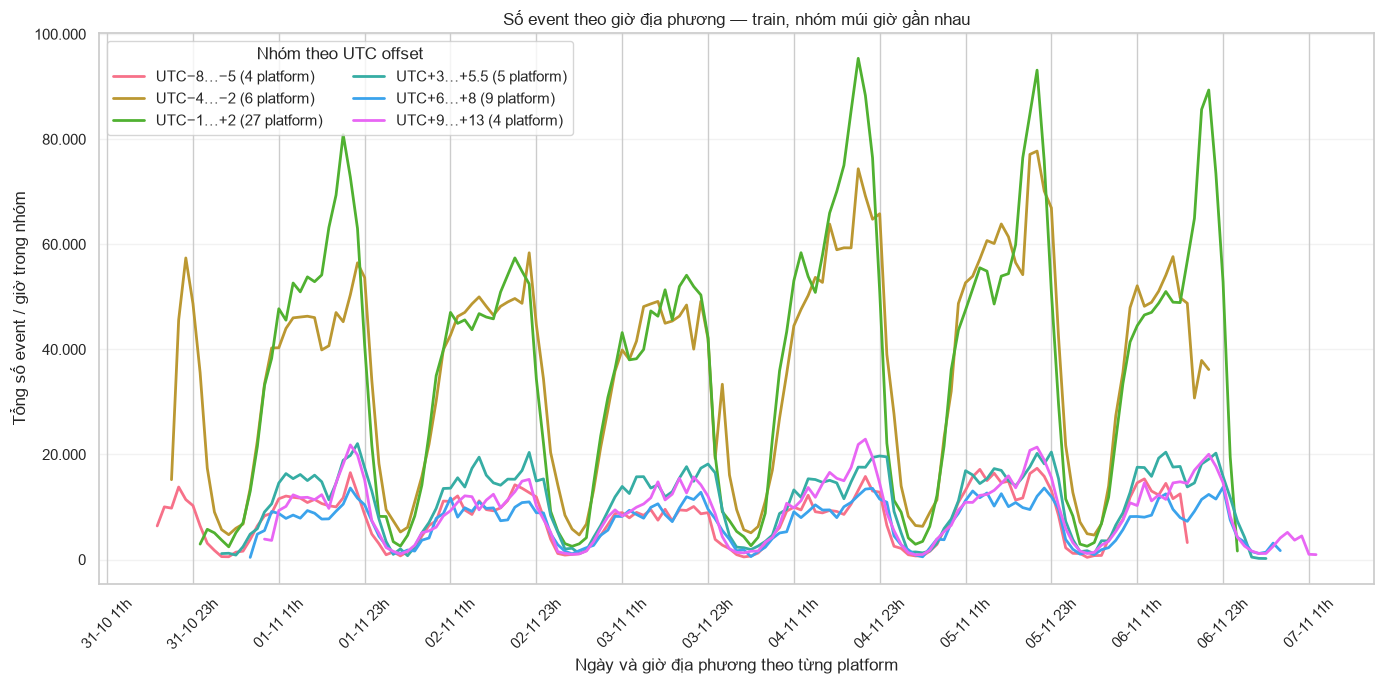

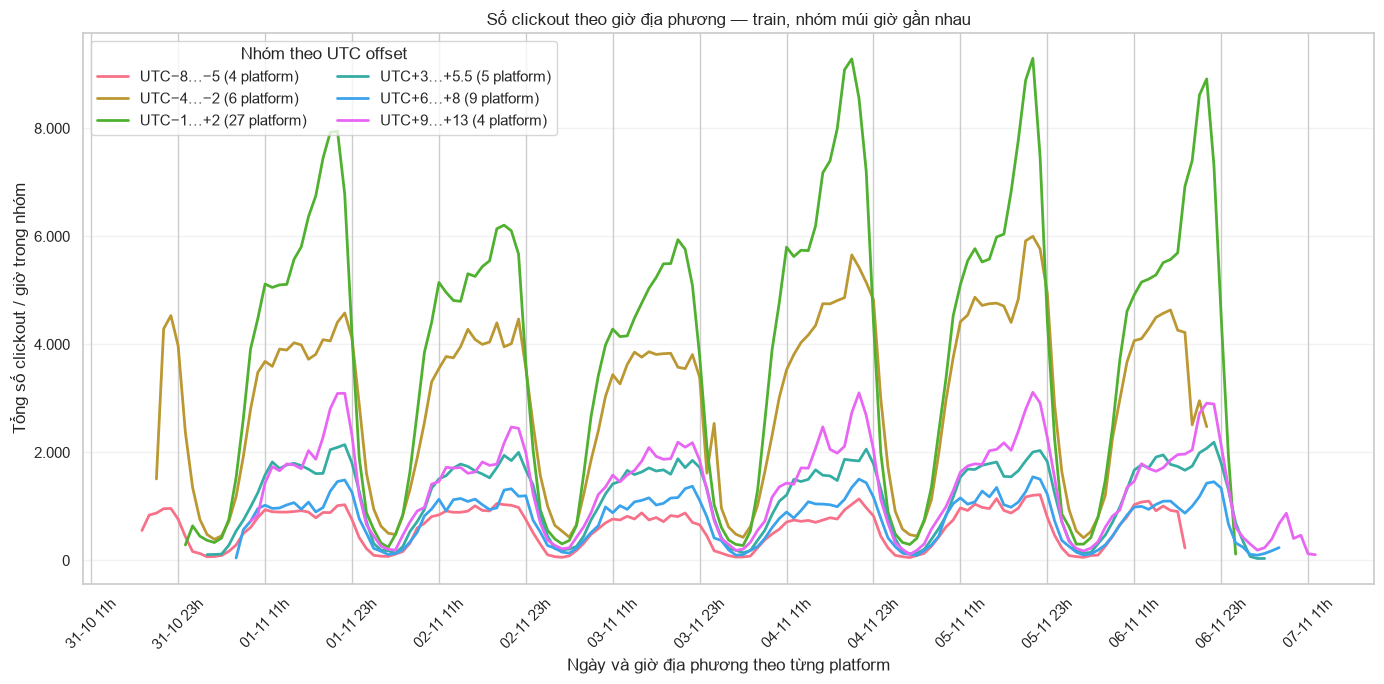

In [41]:
# Cell 3A: Số event và số click theo giờ địa phương, mọi khu vực (train)
# Phạm vi: toàn bộ platform trong train; một đường cho mỗi khu vực
# Output: hai biểu đồ riêng, event count và clickout count theo giờ địa phương
platform_timezone = {
    'AA': ('Thế giới Ả Rập', 'Asia/Riyadh'),
    'AE': ('Các Tiểu vương quốc Ả Rập Thống nhất', 'Asia/Dubai'),
    'AR': ('Argentina', 'America/Argentina/Buenos_Aires'),
    'AT': ('Áo', 'Europe/Vienna'),
    'AU': ('Úc', 'Australia/Sydney'),
    'BE': ('Bỉ', 'Europe/Brussels'),
    'BG': ('Bulgaria', 'Europe/Sofia'),
    'BR': ('Brazil', 'America/Sao_Paulo'),
    'CA': ('Canada', 'America/Toronto'),
    'CH': ('Thụy Sĩ', 'Europe/Zurich'),
    'CL': ('Chile', 'America/Santiago'),
    'CN': ('Trung Quốc', 'Asia/Shanghai'),
    'CO': ('Colombia', 'America/Bogota'),
    'CZ': ('Séc', 'Europe/Prague'),
    'DE': ('Đức', 'Europe/Berlin'),
    'DK': ('Đan Mạch', 'Europe/Copenhagen'),
    'EC': ('Ecuador', 'America/Guayaquil'),
    'ES': ('Tây Ban Nha', 'Europe/Madrid'),
    'FI': ('Phần Lan', 'Europe/Helsinki'),
    'FR': ('Pháp', 'Europe/Paris'),
    'GR': ('Hy Lạp', 'Europe/Athens'),
    'HK': ('Hồng Kông', 'Asia/Hong_Kong'),
    'HR': ('Croatia', 'Europe/Zagreb'),
    'HU': ('Hungary', 'Europe/Budapest'),
    'ID': ('Indonesia', 'Asia/Jakarta'),
    'IE': ('Ireland', 'Europe/Dublin'),
    'IL': ('Israel', 'Asia/Jerusalem'),
    'IN': ('Ấn Độ', 'Asia/Kolkata'),
    'IT': ('Ý', 'Europe/Rome'),
    'JP': ('Nhật Bản', 'Asia/Tokyo'),
    'KR': ('Hàn Quốc', 'Asia/Seoul'),
    'MX': ('Mexico', 'America/Mexico_City'),
    'MY': ('Malaysia', 'Asia/Kuala_Lumpur'),
    'NL': ('Hà Lan', 'Europe/Amsterdam'),
    'NO': ('Na Uy', 'Europe/Oslo'),
    'NZ': ('New Zealand', 'Pacific/Auckland'),
    'PE': ('Peru', 'America/Lima'),
    'PH': ('Philippines', 'Asia/Manila'),
    'PL': ('Ba Lan', 'Europe/Warsaw'),
    'PT': ('Bồ Đào Nha', 'Europe/Lisbon'),
    'RO': ('Romania', 'Europe/Bucharest'),
    'RS': ('Serbia', 'Europe/Belgrade'),
    'RU': ('Nga', 'Europe/Moscow'),
    'SE': ('Thụy Điển', 'Europe/Stockholm'),
    'SG': ('Singapore', 'Asia/Singapore'),
    'SI': ('Slovenia', 'Europe/Ljubljana'),
    'SK': ('Slovakia', 'Europe/Bratislava'),
    'TH': ('Thái Lan', 'Asia/Bangkok'),
    'TR': ('Thổ Nhĩ Kỳ', 'Europe/Istanbul'),
    'TW': ('Đài Loan', 'Asia/Taipei'),
    'UK': ('Vương quốc Anh', 'Europe/London'),
    'US': ('Hoa Kỳ', 'America/New_York'),
    'UY': ('Uruguay', 'America/Montevideo'),
    'VN': ('Việt Nam', 'Asia/Ho_Chi_Minh'),
    'ZA': ('Nam Phi', 'Africa/Johannesburg'),
}

# Chỉ các platform quan sát được trong train; ánh xạ phải bao phủ đủ mọi khu vực.
train_event_totals = Counter()
for (_, platform_code), count in platform_train_minute_event_counts.items():
    train_event_totals[platform_code] += count
observed_platforms = set(train_event_totals)
unknown_platforms = observed_platforms - set(platform_timezone)
if unknown_platforms:
    raise ValueError(f'Chưa có múi giờ đại diện cho platform: {sorted(unknown_platforms)}')
platforms = sorted(observed_platforms)

# Nhóm theo UTC offset tại một mốc cố định nằm trong thời gian quan sát train.
# Mốc cố định giữ nguyên thành viên nhóm dù một số nơi đổi DST trong tuần dữ liệu.
reference_time_utc = pd.Timestamp('2018-11-03 12:00:00', tz='UTC')
timezone_bands = [
    (-8, -5, 'UTC−8…−5'),
    (-4, -2, 'UTC−4…−2'),
    (-1, 2, 'UTC−1…+2'),
    (3, 5.5, 'UTC+3…+5.5'),
    (6, 8, 'UTC+6…+8'),
    (9, 13, 'UTC+9…+13'),
]
platform_group = {}
for code in platforms:
    timezone_name = platform_timezone[code][1]
    offset_hours = reference_time_utc.tz_convert(timezone_name).utcoffset().total_seconds() / 3600
    matching_bands = [
        label for lower, upper, label in timezone_bands
        if lower <= offset_hours <= upper
    ]
    if len(matching_bands) != 1:
        raise ValueError(f'UTC offset {offset_hours} của {code} chưa thuộc đúng một nhóm.')
    platform_group[code] = matching_bands[0]
group_labels = [
    label for _, _, label in timezone_bands
    if any(platform_group[code] == label for code in platforms)
]
group_sizes = Counter(platform_group.values())

# Quy đổi phút UTC theo múi giờ từng platform, gộp thành giờ địa phương,
# sau đó cộng các platform cùng nhóm tại cùng ngày-giờ địa phương.
def group_minute_counts_by_local_hour(minute_counter, platform_code, value_name):
    timezone_name = platform_timezone[platform_code][1]
    rows = [
        {'utc_minute': utc_minute, value_name: count}
        for (utc_minute, code), count in minute_counter.items()
        if code == platform_code
    ]
    if not rows:
        return pd.Series(dtype='int64', name=value_name)
    frame = pd.DataFrame(rows)
    frame['utc_minute'] = pd.to_datetime(frame['utc_minute'], utc=True)
    frame['local_hour'] = (
        frame['utc_minute'].dt.tz_convert(timezone_name).dt.floor(
            'h', ambiguous=False, nonexistent='shift_forward'
        ).dt.tz_localize(None)
    )
    return frame.groupby('local_hour')[value_name].sum().sort_index()


def sum_platforms_by_timezone_group(minute_counter, value_name):
    grouped = {label: pd.Series(dtype='int64', name=value_name) for label in group_labels}
    for code in platforms:
        local_hourly = group_minute_counts_by_local_hour(minute_counter, code, value_name)
        label = platform_group[code]
        grouped[label] = grouped[label].add(local_hourly, fill_value=0)
    return grouped


event_hourly_by_group = sum_platforms_by_timezone_group(
    platform_train_minute_event_counts, 'event_rows'
)
click_hourly_by_group = sum_platforms_by_timezone_group(
    platform_train_minute_click_counts, 'click_count'
)
group_colors = sns.color_palette('husl', n_colors=len(group_labels))


def plot_timezone_group_counts(series_by_group, title, ylabel):
    fig, ax = plt.subplots(figsize=(14, 7))
    for label, color in zip(group_labels, group_colors):
        series = series_by_group[label]
        ax.plot(
            series.index,
            series.values,
            color=color,
            linewidth=2,
            label=f'{label} ({group_sizes[label]} platform)',
        )
    ax.set_title(title)
    ax.set_xlabel('Ngày và giờ địa phương theo từng platform')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(plt.matplotlib.dates.HourLocator(interval=12))
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%m %Hh'))
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda value, _: f'{int(value):,}'.replace(',', '.'))
    )
    ax.tick_params(axis='x', labelrotation=45)
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)
    ax.legend(title='Nhóm theo UTC offset', loc='best', ncol=2)
    plt.tight_layout()
    plt.show()


plot_timezone_group_counts(
    event_hourly_by_group,
    'Số event theo giờ địa phương — train, nhóm múi giờ gần nhau',
    'Tổng số event / giờ trong nhóm',
)
plot_timezone_group_counts(
    click_hourly_by_group,
    'Số clickout theo giờ địa phương — train, nhóm múi giờ gần nhau',
    'Tổng số clickout / giờ trong nhóm',
)


## 4. Schema/action_type

Bảng schema trước, sau đó action_type trong cùng cell.

,file,column,dtype,null_count,empty_count,missing_rate,unique_count,min,max,role,notes
0,train.csv,user_id,string (scan),0,0,0.000000,730803,NaN,NaN,event identifier/context,full-data chunk scan; rows preserved
1,train.csv,session_id,string (scan),0,0,0.000000,910683,NaN,NaN,event identifier/context,full-data chunk scan; rows preserved
2,train.csv,timestamp,string (scan),0,0,0.000000,not_computed,1.541030e+09,1.541549e+09,event identifier/context,full-data chunk scan; rows preserved
3,train.csv,step,string (scan),0,0,0.000000,not_computed,NaN,NaN,event identifier/context,full-data chunk scan; rows preserved
4,train.csv,action_type,string (scan),0,0,0.000000,10,NaN,NaN,event context,full-data chunk scan; rows preserved
5,train.csv,reference,string (scan),0,0,0.000000,not_computed,NaN,NaN,observed clickout label when action_type is cl...,full-data chunk scan; rows preserved
6,train.csv,platform,string (scan),0,0,0.000000,not_computed,NaN,NaN,event context,full-data chunk scan; rows preserved
7,train.csv,city,string (scan),0,0,0.000000,not_computed,NaN,NaN,event context,full-data chunk scan; rows preserved
8,train.csv,device,string (scan),0,0,0.000000,not_computed,NaN,NaN,event context,full-data chunk scan; rows preserved
9,train.csv,current_filters,string (scan),14779880,0,0.927627,not_computed,NaN,NaN,event context,full-data chunk scan; rows preserved


,file,action_type,event_count,event_share
10,test.csv,interaction item image,2578455,0.681710
11,test.csv,clickout item,528779,0.139802
12,test.csv,filter selection,193499,0.051159
14,test.csv,change of sort order,117826,0.031152
13,test.csv,search for destination,115144,0.030443
15,test.csv,interaction item info,68101,0.018005
16,test.csv,interaction item rating,53704,0.014199
17,test.csv,search for item,43065,0.011386
18,test.csv,interaction item deals,42147,0.011143
19,test.csv,search for poi,41615,0.011002


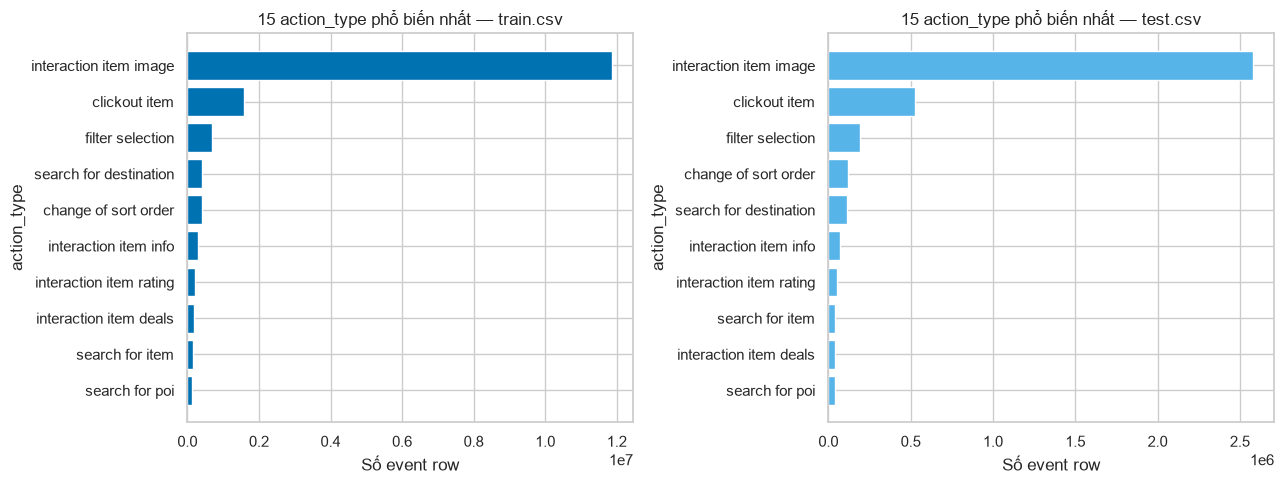

In [5]:
# Cell 4: Schema và action_type
# Input/phạm vi: train/test full-data
# Output: bảng schema rồi bảng/đồ thị action_type
schema_rows = []
for file_name, columns in [('train.csv', train_schema), ('test.csv', test_schema)]:
    for column in columns:
        missing_count = null_counts[(file_name, column)]
        empty_count = empty_counts[(file_name, column)]
        observed = row_counts[file_name]
        unique_count = (
            len(unique_values[(file_name, column)])
            if column in ['user_id', 'session_id', 'action_type']
            else 'not_computed'
        )
        minimum = None
        maximum = None
        if column == 'timestamp' and file_name in timestamp_minmax:
            minimum, maximum = timestamp_minmax[file_name]
        role = 'event context'
        if column in ['user_id', 'session_id', 'timestamp', 'step']:
            role = 'event identifier/context'
        elif column == 'reference':
            role = 'observed clickout label when action_type is clickout item'
        elif column in ['impressions', 'prices']:
            role = 'candidate list / aligned price list'
        schema_rows.append(
            {
                'file': file_name,
                'column': column,
                'dtype': 'string (scan)',
                'null_count': missing_count,
                'empty_count': empty_count,
                'missing_rate': (missing_count + empty_count) / observed if observed else np.nan,
                'unique_count': unique_count,
                'min': minimum,
                'max': maximum,
                'role': role,
                'notes': 'full-data chunk scan; rows preserved',
            }
        )
schema_table = pd.DataFrame(schema_rows)
display(schema_table)

action_rows = [
    {'file': file_name, 'action_type': action, 'event_count': count}
    for (file_name, action), count in action_counts.items()
]
action_summary = pd.DataFrame(action_rows).sort_values(
    ['file', 'event_count', 'action_type'],
    ascending=[True, False, True],
)
action_summary['event_share'] = action_summary['event_count'] / action_summary.groupby('file')['event_count'].transform('sum')
display(action_summary)
fig_action, axes_action = plt.subplots(1, 2, figsize=(13, 5))
for axis, file_name in zip(axes_action, ['train.csv', 'test.csv']):
    file_actions = action_summary[action_summary['file'].eq(file_name)].head(15)
    axis.barh(
        file_actions['action_type'][::-1],
        file_actions['event_count'][::-1],
        color=SPLIT_COLORS[file_name.replace('.csv', '')],
    )
    axis.set_title(f'15 action_type phổ biến nhất — {file_name}')
    axis.set_xlabel('Số event row')
    axis.set_ylabel('action_type')
fig_action.tight_layout()
plt.show()


**Nhận định schema.** Missingness dùng số event làm mẫu số; thiếu không tự động là lỗi.

**Nhận định action_type.** Phân bố hành động không đo chất lượng recommendation.

## 5. Độ dài session

Session length là số event; X là thứ hạng sau sắp xếp.

,file,sessions,events,min_events_per_session,max_events_per_session,mean_events_per_session,p50,p90,p99
0,train.csv,910683,15932992,1,3522,17.495651,4.0,41.0,212.0
1,test.csv,291381,3782335,1,2815,12.980719,3.0,31.0,152.0


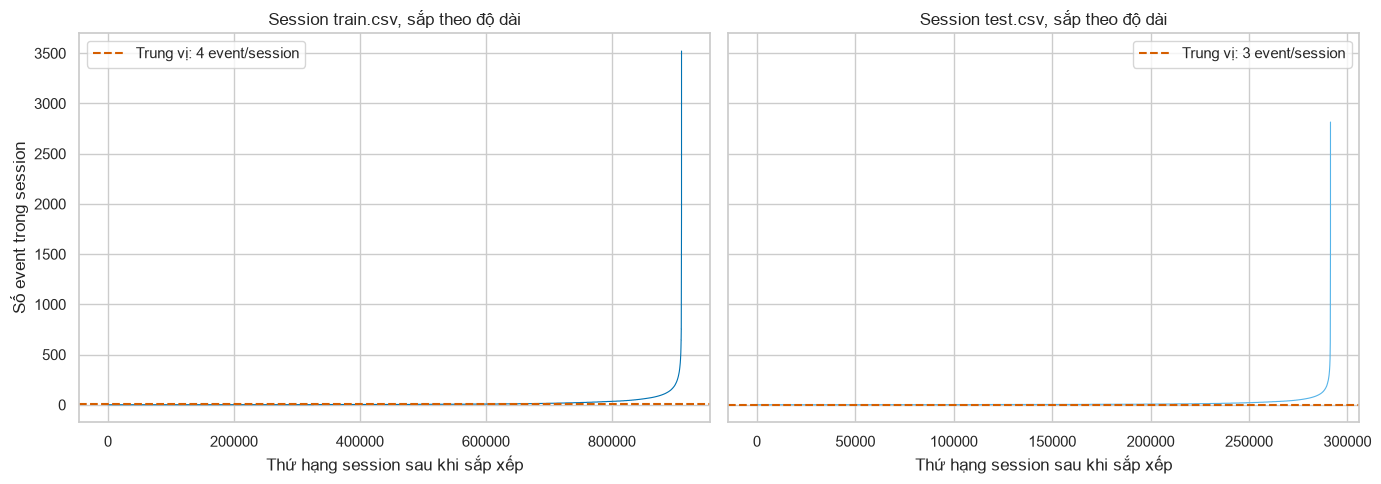

In [6]:
# Cell 5: Độ dài session
# Input/phạm vi: session theo khóa kép
# Output: min/max, phân vị và hai đường session
rows=[]; arr={}
for f in ['train.csv','test.csv']:
 a=np.sort(np.asarray([v for (q,_),v in session_events.items() if q==f],dtype=np.int64)); arr[f]=a
 rows.append({'file':f,'sessions':len(a),'events':row_counts[f],'min_events_per_session':int(a.min()) if len(a) else np.nan,'max_events_per_session':int(a.max()) if len(a) else np.nan,'mean_events_per_session':a.mean() if len(a) else np.nan,'p50':np.quantile(a,.5) if len(a) else np.nan,'p90':np.quantile(a,.9) if len(a) else np.nan,'p99':np.quantile(a,.99) if len(a) else np.nan})
session_length_summary=pd.DataFrame(rows); display(session_length_summary)
fig,axes=plt.subplots(1,2,figsize=(14,5),sharey=True)
for ax,f,color in zip(axes,['train.csv','test.csv'],[SPLIT_COLORS['train'],SPLIT_COLORS['test']]):
 a=arr[f]
 if len(a):
  ax.plot(np.arange(1,len(a)+1),a,color=color,lw=.8); mid=np.median(a); ax.axhline(mid,color=COLORS['negative'],ls='--',label=f'Trung vị: {mid:g} event/session'); ax.legend()
 ax.set(title=f'Session {f}, sắp theo độ dài',xlabel='Thứ hạng session sau khi sắp xếp',ylabel='Số event trong session')
axes[1].set_ylabel(''); plt.tight_layout(); plt.show()


### Số phiên trên mỗi user và thống kê thời lượng phiên

Biểu đồ cho biết phân bố số session trên mỗi user, tách riêng train/test; nhóm các mức dài thành khoảng để dễ đọc. Bảng bên dưới tóm tắt thời lượng theo giờ: nhỏ nhất, P50, P90, P99 và lớn nhất cho mỗi file.

Độ dài tính theo khóa `(file, user_id, session_id)` hiện dùng trong notebook bằng `max(timestamp) - min(timestamp)`; đây là thời gian giữa event đầu và cuối, không phải thời gian user hoạt động liên tục. Session ID bị dùng lại trong cùng user có thể tạo khoảng kéo dài bất thường.


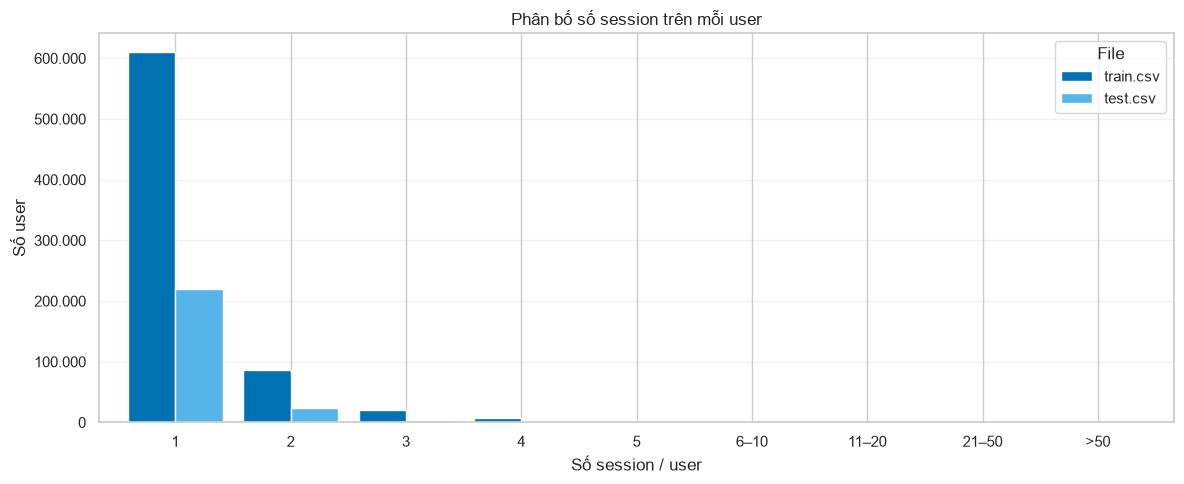

,file,min_time_hours,P50_hours,P90_hours,P99_hours,max_time_hours
0,train.csv,0.0,0.031,0.367,1.370,112.334
1,test.csv,0.0,0.024,0.300,1.232,25.398


In [44]:
# Cell 5A: Số session trên mỗi user và thời lượng phiên theo thời gian
# Input/phạm vi: session_events và session_time_bounds đã tích lũy ở Cell 3
# Output: biểu đồ phân bố session/user và bảng min/P50/P90/P99/max thời lượng
from collections import Counter

# Đếm session duy nhất cho từng user trong từng file theo khóa hiện dùng.
sessions_per_user_counter = Counter()
for file_name, session_key in session_events:
    user_id, session_id = session_key
    sessions_per_user_counter[(file_name, user_id)] += 1

# Gom phần đuôi dài để số user ở các mức session thấp vẫn dễ so sánh.
session_bin_labels = ['1', '2', '3', '4', '5', '6–10', '11–20', '21–50', '>50']
session_user_bin_counts = Counter()
for (file_name, user_id), count in sessions_per_user_counter.items():
    if count <= 5:
        group = str(count)
    elif count <= 10:
        group = '6–10'
    elif count <= 20:
        group = '11–20'
    elif count <= 50:
        group = '21–50'
    else:
        group = '>50'
    session_user_bin_counts[(file_name, group)] += 1
user_distribution = pd.DataFrame(
    {
        file_name: [session_user_bin_counts[(file_name, label)] for label in session_bin_labels]
        for file_name in ['train.csv', 'test.csv']
    },
    index=session_bin_labels,
)
fig, ax = plt.subplots(figsize=(12, 5))
user_distribution.plot(
    kind='bar',
    ax=ax,
    color=[SPLIT_COLORS['train'], SPLIT_COLORS['test']],
    width=0.82,
)
ax.set(
    title='Phân bố số session trên mỗi user',
    xlabel='Số session / user',
    ylabel='Số user',
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f'{int(value):,}'.replace(',', '.'))
)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
ax.legend(title='File')
plt.tight_layout()
plt.show()

# Chuẩn bị mảng gọn theo split; trục x là thứ tự session sau khi sắp theo lúc bắt đầu.
files = ['train.csv', 'test.csv']
duration_capacity = Counter(key[0] for key in session_time_bounds)
duration_arrays = {
    file_name: np.empty((duration_capacity[file_name], 2), dtype=np.float64)
    for file_name in files
}
duration_rows_written = Counter()
for (file_name, session_key), (start_timestamp, end_timestamp) in session_time_bounds.items():
    if file_name not in duration_arrays or pd.isna(start_timestamp) or pd.isna(end_timestamp):
        continue
    duration_hours = max(0.0, float(end_timestamp) - float(start_timestamp)) / 3600
    row_index = duration_rows_written[file_name]
    duration_arrays[file_name][row_index] = (float(start_timestamp), duration_hours)
    duration_rows_written[file_name] += 1

# Thống kê thời lượng theo từng split; các phân vị đo bằng giờ/session.
duration_summary_rows = []
for file_name in files:
    durations = duration_arrays[file_name][:duration_rows_written[file_name], 1]
    if len(durations):
        duration_summary_rows.append(
            {
                'file': file_name,
                'min_time_hours': float(np.min(durations)),
                'P50_hours': float(np.quantile(durations, 0.50)),
                'P90_hours': float(np.quantile(durations, 0.90)),
                'P99_hours': float(np.quantile(durations, 0.99)),
                'max_time_hours': float(np.max(durations)),
            }
        )
duration_summary = pd.DataFrame(duration_summary_rows)
display(duration_summary.round(3))


Đơn vị thời gian là giờ


## 6. Chất lượng dữ liệu

Duplicate chỉ được kiểm tra trong chunk.

,scope,observed_value,unit,status,denominator,evidence,notes
0,train.csv,15932992,event row,measured,15932992,tổng len(chunk) trên toàn bộ lượt đọc,header không tính vào số dòng
1,train.csv,1586586,clickout query,measured,15932992,action_type == 'clickout item',query_id gồm source_file và source_row_id
2,train.csv,0,timestamp parse failure,measured,15932992,timestamp không chuyển được sang số,timestamp được giả định là Unix seconds UTC
3,train.csv,0,negative timestamp,measured,15932992,timestamp < 0,không xóa dòng
4,train.csv,0,missing/non-integer/step < 1,measured,15932992,numeric step validation,rows preserved
5,train.csv,0,rows in duplicate candidate-key groups,measured,15932992,"user_id, session_id, timestamp, step",duplicates checked within each chunk only
6,train.csv,0,rows in duplicate full-row groups,measured,15932992,full-row duplicate check within each chunk,cross-chunk duplicate rows not checked
7,test.csv,3782335,event row,measured,3782335,tổng len(chunk) trên toàn bộ lượt đọc,header không tính vào số dòng
8,test.csv,528779,clickout query,measured,3782335,action_type == 'clickout item',query_id gồm source_file và source_row_id
9,test.csv,0,timestamp parse failure,measured,3782335,timestamp không chuyển được sang số,timestamp được giả định là Unix seconds UTC


,file,column,null_count,empty_count,missing_count,denominator,missing_rate
0,train.csv,user_id,0,0,0,15932992,0.000000
1,train.csv,session_id,0,0,0,15932992,0.000000
2,train.csv,timestamp,0,0,0,15932992,0.000000
3,train.csv,step,0,0,0,15932992,0.000000
4,train.csv,action_type,0,0,0,15932992,0.000000
5,train.csv,reference,0,0,0,15932992,0.000000
6,train.csv,platform,0,0,0,15932992,0.000000
7,train.csv,city,0,0,0,15932992,0.000000
8,train.csv,device,0,0,0,15932992,0.000000
9,train.csv,current_filters,14779880,0,14779880,15932992,0.927627


,file,reference_type,count
0,train.csv,numeric,1586586
1,train.csv,non_numeric,0
2,test.csv,numeric,275206
3,test.csv,non_numeric,0


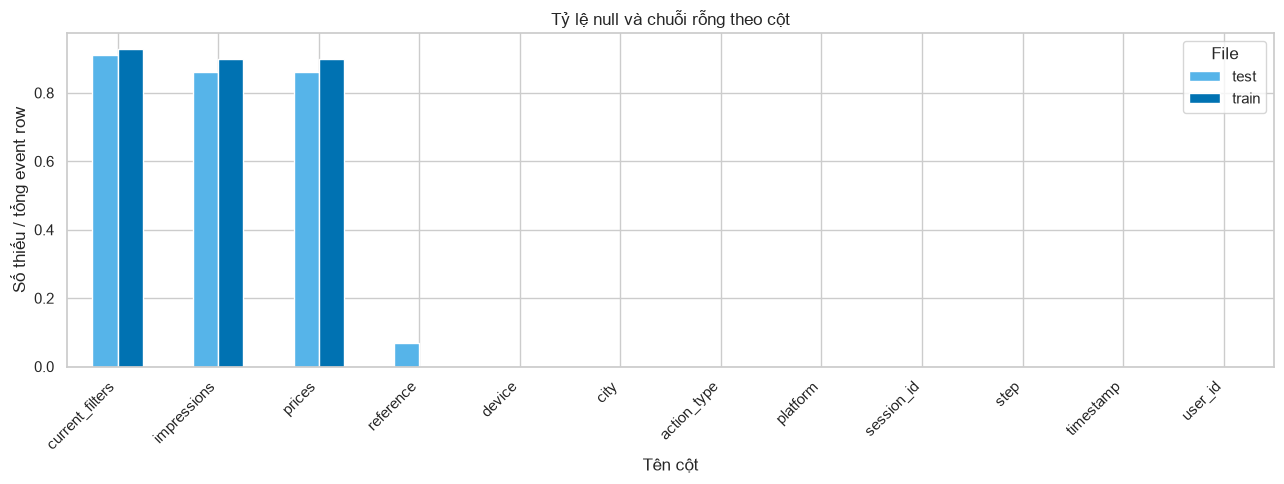

In [7]:
# Cell 6: Quality và missingness
# Input/phạm vi: train/test; duplicate trong chunk
# Output: bảng chất lượng và đồ thị missingness
quality_rows = []
missingness_rows = []
for file_name in ['train.csv', 'test.csv']:
    total_rows = row_counts[file_name]
    quality_rows.extend(
        [
            {
                'scope': file_name,
                'observed_value': total_rows,
                'unit': 'event row',
                'status': 'measured',
                'denominator': total_rows,
                'evidence': 'tổng len(chunk) trên toàn bộ lượt đọc',
                'notes': 'header không tính vào số dòng',
            },
            {
                'scope': file_name,
                'observed_value': clickout_rows[file_name],
                'unit': 'clickout query',
                'status': 'measured',
                'denominator': total_rows,
                'evidence': "action_type == 'clickout item'",
                'notes': 'query_id gồm source_file và source_row_id',
            },
            {
                'scope': file_name,
                'observed_value': bad_timestamp[file_name],
                'unit': 'timestamp parse failure',
                'status': 'measured',
                'denominator': total_rows,
                'evidence': 'timestamp không chuyển được sang số',
                'notes': 'timestamp được giả định là Unix seconds UTC',
            },
            {
                'scope': file_name,
                'observed_value': negative_timestamp[file_name],
                'unit': 'negative timestamp',
                'status': 'measured',
                'denominator': total_rows,
                'evidence': 'timestamp < 0',
                'notes': 'không xóa dòng',
            },
            {
                'scope': file_name,
                'observed_value': bad_step[file_name],
                'unit': 'missing/non-integer/step < 1',
                'status': 'measured',
                'denominator': total_rows,
                'evidence': 'numeric step validation',
                'notes': 'rows preserved',
            },
            {
                'scope': file_name,
                'observed_value': dup_key_counts[file_name],
                'unit': 'rows in duplicate candidate-key groups',
                'status': 'measured',
                'denominator': total_rows,
                'evidence': 'user_id, session_id, timestamp, step',
                'notes': 'duplicates checked within each chunk only',
            },
            {
                'scope': file_name,
                'observed_value': duplicate_chunk_rows[file_name],
                'unit': 'rows in duplicate full-row groups',
                'status': 'measured',
                'denominator': total_rows,
                'evidence': 'full-row duplicate check within each chunk',
                'notes': 'cross-chunk duplicate rows not checked',
            },
        ]
    )
    for column in train_schema if file_name == 'train.csv' else test_schema:
        null_count = null_counts[(file_name, column)]
        empty_count = empty_counts[(file_name, column)]
        missing_count = null_count + empty_count
        missingness_rows.append(
            {
                'file': file_name,
                'column': column,
                'null_count': null_count,
                'empty_count': empty_count,
                'missing_count': missing_count,
                'denominator': total_rows,
                'missing_rate': missing_count / total_rows if total_rows else np.nan,
            }
        )

multi_user_session_ids = {
    session_id: users
    for session_id, users in session_id_users.items()
    if len(users) > 1
}
quality_rows.append(
    {
        'scope': 'train + test',
        'observed_value': len(multi_user_session_ids),
        'unit': 'session_id linked to multiple user_id values',
        'status': 'measured',
        'denominator': len(session_id_users),
        'evidence': 'distinct user_id sets accumulated across chunks',
        'notes': 'session aggregation uses the composite key (user_id, session_id)',
    }
)
quality_table = pd.DataFrame(quality_rows)
missingness_table = pd.DataFrame(missingness_rows)
reference_type_table = pd.DataFrame(
    [
        {'file': file_name, 'reference_type': ref_type, 'count': reference_type_counts[(file_name, ref_type)]}
        for file_name in ['train.csv', 'test.csv']
        for ref_type in ['numeric', 'non_numeric']
    ]
)
display(quality_table)
display(missingness_table)
display(reference_type_table)

# Cell: Biểu đồ tỷ lệ null/rỗng theo cột và file

missing_plot = missingness_table.copy()
missing_plot['file_label'] = missing_plot['file'].str.replace('.csv', '', regex=False)
missing_wide = missing_plot.pivot(index='column', columns='file_label', values='missing_rate').fillna(0)
missing_wide = missing_wide.loc[missing_wide.max(axis=1).sort_values(ascending=False).index]
missing_wide.plot(
    kind='bar',
    figsize=(13, 5),
    color=[SPLIT_COLORS.get(name, COLORS['neutral']) for name in missing_wide.columns],
)
plt.title('Tỷ lệ null và chuỗi rỗng theo cột')
plt.xlabel('Tên cột')
plt.ylabel('Số thiếu / tổng event row')
plt.xticks(rotation=45, ha='right')
plt.legend(title='File')
plt.tight_layout()
plt.show()


**Nhận định.** reference ở action khác clickout không nhất thiết là hotel ID; reference test bị ẩn. Một session dùng user_id và session_id. Duplicate chỉ kiểm tra trong chunk, chưa kiểm tra xuyên chunk.

## 7. Clickout và candidate

Đánh giá nhãn chỉ trên train có candidate hợp lệ.

**Lý do clickout.** Điều kiện chất lượng có thể chồng lấp; đếm token/cặp giá có đơn vị riêng, không cộng với số query.

,file,condition,count,unit
0,train.csv,missing_or_empty_reference,0,clickout query
1,train.csv,missing_or_empty_impressions,0,clickout query
2,train.csv,empty_candidate_token,0,candidate token
3,train.csv,no_parseable_candidate_ids,0,clickout query
4,train.csv,parseable_nonempty_impressions,1586586,clickout query
5,train.csv,labeled_with_parseable_impressions,1586586,clickout query
6,train.csv,clicked_item_not_in_impressions,749,clickout query
7,train.csv,clicked_item_in_impressions,1585837,clickout query
8,train.csv,duplicate_candidate_entries,0,clickout query
9,train.csv,duplicate_candidate_entry_count,0,candidate token dư do trùng


**Clickout và candidate.** `impressions_with_parseable_candidate_count` đếm query có ít nhất một candidate ID hợp lệ. Ba trạng thái impressions loại trừ nhau; membership chỉ tính trên query có nhãn và candidate parse được.

,file,clickout_query_count,reference_observed_count,reference_missing_count,impressions_missing_or_empty_count,impressions_present_no_parseable_item_count,impressions_with_parseable_candidate_count,labeled_query_with_parseable_candidate_count,clicked_item_in_impressions_count,clicked_item_outside_impressions_count,parseable_impressions_rate_of_clickouts,in_list_rate_of_labeled_candidate_queries
0,train.csv,1586586,1586586,0,0,0,1586586,1586586,1585837,749,1.0,0.999528
1,test.csv,528779,275206,253573,0,0,528779,275206,275059,147,1.0,0.999466


Tổng reference quan sát được ở clickout train + test: 1,861,792
Tổng clicked-in-list ở clickout train: 1,585,837
Mẫu số: clickout train có reference và ít nhất một candidate ID parse được.


,label_status,query_count,denominator_labeled_candidate_queries,query_share
0,reference trong impressions,1585837,1586586,0.999528
1,reference ngoài impressions,749,1586586,0.000472


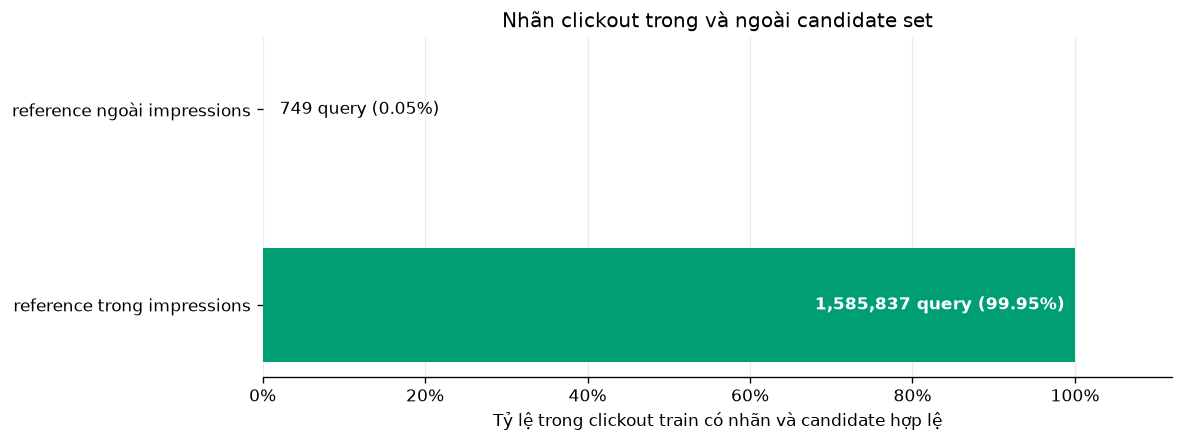

In [8]:
# Cell 7: Clickout và nhãn
# Input/phạm vi: nhãn train có candidate hợp lệ
# Output: bảng trạng thái và hai panel nhãn
# Phân biệt số đếm query với số đếm token hoặc cặp giá.
reason_units = {
    'empty_candidate_token': 'candidate token',
    'duplicate_candidate_entry_count': 'candidate token dư do trùng',
    'missing_aligned_price_pairs': 'candidate-price pair',
    'extra_unaligned_price_entries': 'price token dư',
}
reason_names = [
    'missing_or_empty_reference', 'missing_or_empty_impressions',
    'empty_candidate_token', 'no_parseable_candidate_ids',
    'parseable_nonempty_impressions', 'labeled_with_parseable_impressions',
    'clicked_item_not_in_impressions', 'clicked_item_in_impressions',
    'duplicate_candidate_entries', 'duplicate_candidate_entry_count',
    'missing_or_empty_prices', 'price_impression_length_mismatch',
    'missing_aligned_price_pairs', 'extra_unaligned_price_entries',
]

# Hiển thị cả điều kiện có số đếm bằng 0; các nguyên nhân có thể chồng lấp.
reason_df = pd.DataFrame([
    {
        'file': file_name,
        'condition': condition,
        'count': clickout_reasons.get((file_name, condition), 0),
        'unit': reason_units.get(condition, 'clickout query'),
    }
    for file_name in ['train.csv', 'test.csv']
    for condition in reason_names
])
display(Markdown(
    '**Lý do clickout.** Điều kiện chất lượng có thể chồng lấp; '
    'đếm token/cặp giá có đơn vị riêng, không cộng với số query.'
))
display(reason_df)

# Chia trạng thái impressions thành nhóm loại trừ nhau để đối chiếu tổng query.
# no_parseable_candidate_ids cũng gồm impressions thiếu/rỗng nên hai hàng đó
# trong reason_df không phải các nhóm để cộng thành tổng.
status_rows = []
for file_name in ['train.csv', 'test.csv']:
    total_clickouts = clickout_rows[file_name]
    missing_reference = clickout_reasons.get((file_name, 'missing_or_empty_reference'), 0)
    missing_impressions = clickout_reasons.get((file_name, 'missing_or_empty_impressions'), 0)
    parseable_impressions = clickout_reasons.get((file_name, 'parseable_nonempty_impressions'), 0)
    present_without_parseable_item = total_clickouts - missing_impressions - parseable_impressions
    labeled_with_parseable = clickout_reasons.get((file_name, 'labeled_with_parseable_impressions'), 0)
    clicked_in = clickout_reasons.get((file_name, 'clicked_item_in_impressions'), 0)
    clicked_out = clickout_reasons.get((file_name, 'clicked_item_not_in_impressions'), 0)

    # Kiểm tra trạng thái impressions bao phủ đủ query và membership đủ điều kiện.
    assert missing_impressions + present_without_parseable_item + parseable_impressions == total_clickouts
    assert clicked_in + clicked_out == labeled_with_parseable

    status_rows.append({
        'file': file_name,
        'clickout_query_count': total_clickouts,
        'reference_observed_count': total_clickouts - missing_reference,
        'reference_missing_count': missing_reference,
        'impressions_missing_or_empty_count': missing_impressions,
        'impressions_present_no_parseable_item_count': present_without_parseable_item,
        'impressions_with_parseable_candidate_count': parseable_impressions,
        'labeled_query_with_parseable_candidate_count': labeled_with_parseable,
        'clicked_item_in_impressions_count': clicked_in,
        'clicked_item_outside_impressions_count': clicked_out,
        'parseable_impressions_rate_of_clickouts': parseable_impressions / total_clickouts if total_clickouts else np.nan,
        'in_list_rate_of_labeled_candidate_queries': clicked_in / labeled_with_parseable if labeled_with_parseable else np.nan,
    })

clickout_candidate_summary = pd.DataFrame(status_rows)
display(Markdown(
    '**Clickout và candidate.** `impressions_with_parseable_candidate_count` '
    'đếm query có ít nhất một candidate ID hợp lệ. Ba trạng thái impressions '
    'loại trừ nhau; membership chỉ tính trên query có nhãn và candidate parse được.'
))
display(clickout_candidate_summary)
print('Tổng reference quan sát được ở clickout train + test:', f'{clickout_label_total:,}')
print('Tổng clicked-in-list ở clickout train:', f'{clicked_in_list:,}')
print('Mẫu số: clickout train có reference và ít nhất một candidate ID parse được.')

# Cell: Biểu đồ clickout label nằm trong hay ngoài candidate set

labeled_candidate_queries = clickout_reasons.get(('train.csv', 'labeled_with_parseable_impressions'), 0)
clickout_membership = pd.DataFrame([
    {'label_status': 'reference trong impressions', 'query_count': clicked_in_list},
    {'label_status': 'reference ngoài impressions', 'query_count': clicked_out_of_list},
])
clickout_membership['denominator_labeled_candidate_queries'] = labeled_candidate_queries
clickout_membership['query_share'] = (
    clickout_membership['query_count'] / labeled_candidate_queries
    if labeled_candidate_queries
    else np.nan
)
display(clickout_membership)
fig, ax = plt.subplots(figsize=(10, 3.8))
labels = clickout_membership['label_status'].tolist()
shares = clickout_membership['query_share'].fillna(0).to_numpy()
counts = clickout_membership['query_count'].to_numpy()
bar_colors = [COLORS['positive'], COLORS['negative']]
bars = ax.barh(labels, shares, color=bar_colors, height=0.58)
for bar, count, share in zip(bars, counts, shares):
    label = f'{count:,} query ({share:.2%})'
    if share >= 0.15:
        ax.text(share - 0.012, bar.get_y() + bar.get_height() / 2, label,
                ha='right', va='center', color='white', fontsize=10, fontweight='bold')
    else:
        ax.annotate(label, xy=(share, bar.get_y() + bar.get_height() / 2), xytext=(10, 0),
                    textcoords='offset points', ha='left', va='center', fontsize=10)
ax.set_xlim(0, 1.12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))
ax.set(title='Nhãn clickout trong và ngoài candidate set',
       xlabel='Tỷ lệ trong clickout train có nhãn và candidate hợp lệ')
ax.grid(axis='x', alpha=0.25)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()
plt.show()


**Nhận định.** Reference trong impressions đo độ bao phủ candidate set, không phải accuracy hay booking.

## 8. Độ thưa

S = 1 − |E|/(|L|×|R|); cặp vắng không đồng nghĩa dislike.

In [9]:
# Cell 8: Độ thưa S
# Input/phạm vi: quan hệ session-item, user-item trong train; query-item trong train/test
# Output: số nút, cạnh duy nhất, cặp có thể có và độ thưa S (%)
def sparsity_row(name, left_count, item_count, edge_count):
    possible = left_count * item_count
    return {
        'Quan hệ': name,
        'Số nút trái': left_count,
        'Số khách sạn': item_count,
        'Số cặp duy nhất': edge_count,
        'Số cặp tối đa': possible,
        'Độ thưa S (%)': 1 - edge_count / possible if possible else np.nan,
    }

# Dùng các bộ đếm đã tích lũy; query_id là duy nhất theo file và source row.
session_edges = set(positive_session_item)
user_edges = set(positive_user_item)
query_count = sum(clickout_reasons[(f, 'parseable_nonempty_impressions')] for f in ['train.csv', 'test.csv'])
candidate_edge_count = sum(candidate_count.values())
rows = [
    sparsity_row('Session–khách sạn đã click (train)', len({x for x, _ in session_edges}), len({item for _, item in session_edges}), len(session_edges)),
    sparsity_row('User–khách sạn đã click (train)', len({x for x, _ in user_edges}), len({item for _, item in user_edges}), len(user_edges)),
    sparsity_row('Clickout query–khách sạn trong impressions (train + test)', query_count, len(candidate_item_ids), candidate_edge_count),
]
sparsity_table = pd.DataFrame(rows)
sparsity_table['Độ thưa S (%)'] = sparsity_table['Độ thưa S (%)'].map(lambda x: f'{x:.2%}' if pd.notna(x) else '—')
display(sparsity_table)


,Quan hệ,Số nút trái,Số khách sạn,Số cặp duy nhất,Số cặp tối đa,Độ thưa S (%)
0,Session–khách sạn đã click (train),826842,289506,1354909,239375720052,100.00%
1,User–khách sạn đã click (train),717774,289506,1306901,207799879644,100.00%
2,Clickout query–khách sạn trong impressions (tr...,2115365,905289,48524284,1915016665485,100.00%


**Nhận định.** S cao phản ánh quan hệ thưa, không nói người dùng không thích cặp vắng.

## 9. Gini

Gini chỉ trên khách sạn có click quan sát được.

In [10]:
# Cell 9: Gini
# Input/phạm vi: session duy nhất click mỗi khách sạn train
# Output: bảng Gini
item_degree_by_session=Counter(item for _,item in set(positive_session_item)); deg=np.sort(np.asarray(list(item_degree_by_session.values()),dtype=float))
if len(deg) and deg.sum(): n=len(deg); value=2*np.sum(np.arange(1,n+1)*deg)/(n*deg.sum())-(n+1)/n; status='measured'
else: value=np.nan; status='not_applicable'
display(pd.DataFrame([{'Số khách sạn có click':len(deg),'Số cặp session–khách sạn':int(deg.sum()) if len(deg) else 0,'Hệ số Gini (0–1)':value,'Đơn vị':'session duy nhất / khách sạn','Trạng thái':status}]))


,Số khách sạn có click,Số cặp session–khách sạn,Hệ số Gini (0–1),Đơn vị,Trạng thái
0,289506,1354909,0.62596,session duy nhất / khách sạn,measured


**Nhận định.** Gini đo tập trung, không đo độ chính xác hay nguyên nhân phổ biến.

## 10. Candidate/query

Candidate/query là số khách sạn duy nhất trong impressions.

,Số clickout query,Trung vị,P90,P95,P99,Lớn nhất,Đúng 25 candidate (%),Ít hơn 25 candidate (%),Số query vượt 25
0,2115365,25.0,25.0,25.0,25.0,25,77.69%,22.31%,0


,Số candidate,Số clickout query,Tỷ lệ (%)
0,1,5715,0.27%
1,2,6895,0.33%
2,3,7581,0.36%
3,4,8226,0.39%
4,5,8854,0.42%
5,6,9516,0.45%
6,7,9970,0.47%
7,8,10486,0.50%
8,9,11471,0.54%
9,10,12940,0.61%


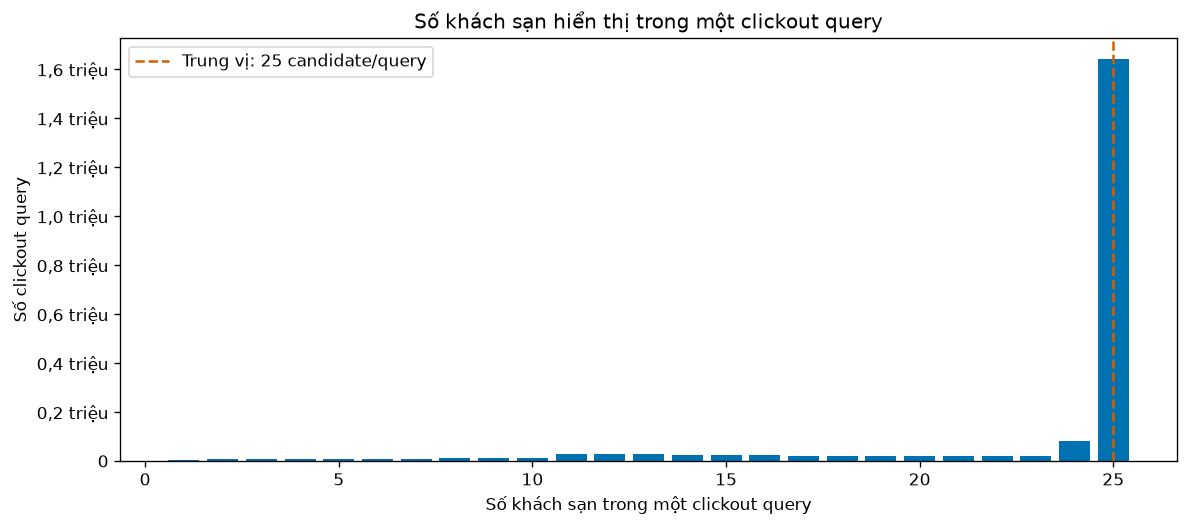

In [11]:
# Cell 10: Số candidate/query
# Input/phạm vi: clickout train/test hợp lệ
# Output: bảng phân vị, phân bố và đồ thị
size_series=pd.Series(all_candidate_sizes,dtype='int64')
if len(size_series):
 counts=size_series.value_counts().sort_index().reindex(range(1,int(size_series.max())+1),fill_value=0)
 summary=pd.DataFrame([{'Số clickout query':len(size_series),'Trung vị':size_series.median(),'P90':size_series.quantile(.9),'P95':size_series.quantile(.95),'P99':size_series.quantile(.99),'Lớn nhất':size_series.max(),'Đúng 25 candidate (%)':f'{size_series.eq(25).mean():.2%}','Ít hơn 25 candidate (%)':f'{size_series.lt(25).mean():.2%}','Số query vượt 25':int(size_series.gt(25).sum())}])
 dist=pd.DataFrame({'Số candidate':counts.index,'Số clickout query':counts.values,'Tỷ lệ (%)':counts.values/len(size_series)})
else: counts=pd.Series(dtype=int); summary=pd.DataFrame([{'Số clickout query':0,'Trạng thái':'not_applicable'}]); dist=pd.DataFrame()
display(summary)
if len(dist): display(dist.assign(**{'Tỷ lệ (%)':dist['Tỷ lệ (%)'].map(lambda x:f'{x:.2%}') }))
if len(size_series):
 fig,ax=plt.subplots(figsize=(10,4.5)); ax.bar(counts.index,counts.values,color=COLORS['primary']); mid=size_series.median(); ax.axvline(mid,color=COLORS['negative'],ls='--',label=f'Trung vị: {mid:g} candidate/query'); ax.set(title='Số khách sạn hiển thị trong một clickout query',xlabel='Số khách sạn trong một clickout query',ylabel='Số clickout query'); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value,_: '0' if value == 0 else f'{value/1_000_000:.1f}'.replace('.', ',')+' triệu')); ax.legend(); plt.tight_layout(); plt.show()


**Nhận định.** Tỷ lệ đúng 25, dưới 25 và query vượt 25 dùng mẫu số query hợp lệ train/test.

## 11. Tỷ lệ được chọn

Tử số là candidate chọn; mẫu số là candidate hiển thị.

In [12]:
# Cell 11: Tỷ lệ candidate được chọn
# Input/phạm vi: train clickout reference trong impressions
# Output: bảng tỷ lệ chung
eligible_queries=clicked_in_list; shown_candidates=sum(train_candidate_exposure.values()); selected_candidates=sum(train_clicked_candidate_by_item.values()); selected_rate=selected_candidates/shown_candidates if shown_candidates else np.nan
display(pd.DataFrame([{'Clickout query đủ điều kiện':eligible_queries,'Candidate đã hiển thị':shown_candidates,'Candidate được chọn':selected_candidates,'Tỷ lệ được chọn (%)':f'{selected_rate:.2%}' if pd.notna(selected_rate) else '—'}]))


,Clickout query đủ điều kiện,Candidate đã hiển thị,Candidate được chọn,Tỷ lệ được chọn (%)
0,1585837,36361011,1585837,4.36%


**Nhận định.** Tỷ lệ được chọn không phải accuracy hay booking và phụ thuộc số candidate mỗi query.

## 12. Theo thiết bị

Hai panel có đơn vị khác nhau; nhóm nhỏ dưới ngưỡng được gộp.

,Loại thiết bị,Số clickout query,Số candidate đã hiển thị,Số candidate được chọn,Tỷ lệ candidate được chọn (%)
0,mobile,873884,19940951,873884,4.38%
1,desktop,577293,13312701,577293,4.34%
2,tablet,134660,3107359,134660,4.33%


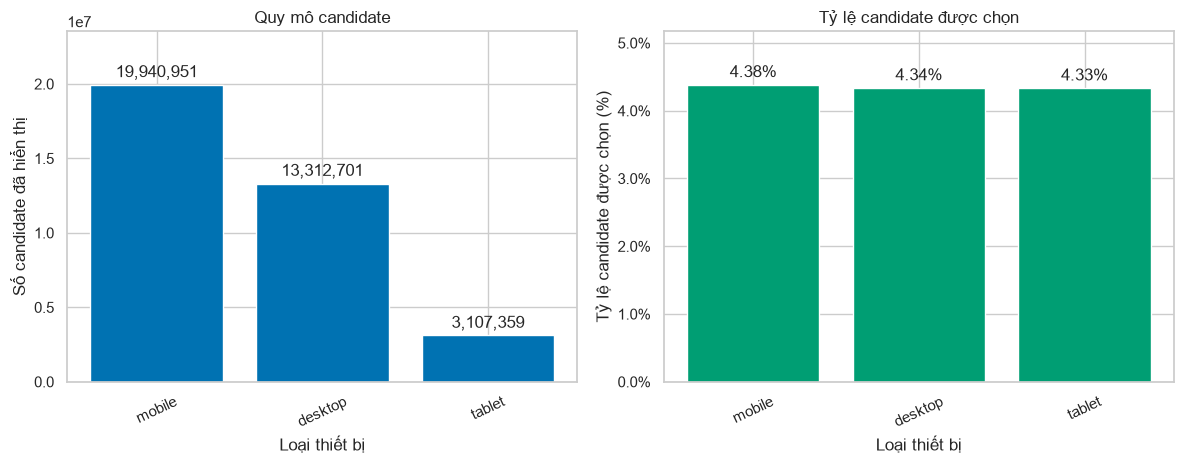

In [13]:
# Cell 12: Tỷ lệ theo thiết bị
# Input/phạm vi: train đủ điều kiện; nhóm dưới 1.000 candidate
# Output: bảng và hai panel
minimum_support=1000
device_relation=pd.DataFrame([{'device':d,'queries':len(device_query_ids[d]),'shown':n,'selected':device_clicked_candidates[d]} for d,n in device_candidate_exposure.items()])
if len(device_relation):
 rare=device_relation.shown<minimum_support; small=device_relation.loc[rare]; device_relation=device_relation.loc[~rare].copy()
 if len(small): device_relation=pd.concat([device_relation,pd.DataFrame([{'device':'Khác','queries':small.queries.sum(),'shown':small.shown.sum(),'selected':small.selected.sum()}])],ignore_index=True)
 device_relation['rate']=device_relation.selected/device_relation.shown.replace(0,np.nan); device_relation=device_relation.sort_values('shown',ascending=False)
d=device_relation.rename(columns={'device':'Loại thiết bị','queries':'Số clickout query','shown':'Số candidate đã hiển thị','selected':'Số candidate được chọn','rate':'Tỷ lệ candidate được chọn'})
display(d.assign(**{'Tỷ lệ candidate được chọn (%)':d['Tỷ lệ candidate được chọn'].map(lambda x:f'{x:.2%}' if pd.notna(x) else '—')}).drop(columns='Tỷ lệ candidate được chọn'))
fig,axes=plt.subplots(1,2,figsize=(12,4.8)); bars=axes[0].bar(d['Loại thiết bị'],d['Số candidate đã hiển thị'],color=COLORS['primary']); axes[0].bar_label(bars,labels=[f'{x:,.0f}' for x in d['Số candidate đã hiển thị']],padding=3); axes[0].set(title='Quy mô candidate',xlabel='Loại thiết bị',ylabel='Số candidate đã hiển thị')
bars=axes[1].bar(d['Loại thiết bị'],d['Tỷ lệ candidate được chọn'],color=COLORS['positive']); axes[1].bar_label(bars,labels=[f'{x:.2%}' for x in d['Tỷ lệ candidate được chọn']],padding=3); axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'{x:.1%}')); axes[1].set(title='Tỷ lệ candidate được chọn',xlabel='Loại thiết bị',ylabel='Tỷ lệ candidate được chọn (%)')
for ax in axes: ax.tick_params(axis='x',rotation=25); ax.margins(y=.18)
plt.tight_layout(); plt.show()


**Nhận định.** Panel trái là quy mô; panel phải là tỷ lệ. Chênh lệch không chứng minh thiết bị gây click.

## 13. Step đầu tiên

Session không click được báo riêng, không gán step 0.

In [14]:
# Cell 13: Step clickout đầu tiên
# Input/phạm vi: session train
# Output: bảng trạng thái và đồ thị
session_rows=[]
for (file_name,session_key),event_count in session_events.items():
    if file_name!='train.csv': continue
    detail=train_session_details.get(session_key,[np.nan,0,np.nan])
    bounds=session_time_bounds.get(('train.csv',session_key),(np.nan,np.nan))
    session_rows.append({'user_id':session_key[0],'session_id':session_key[1],'clickout_count':detail[1],'first_click_step':detail[2],'session_start_timestamp':bounds[0]})
session_click_summary = pd.DataFrame(session_rows)
session_click_summary['has_clickout'] = session_click_summary.clickout_count.gt(0)
raw_steps = pd.to_numeric(session_click_summary.first_click_step, errors='coerce')
valid_step = raw_steps.notna() & raw_steps.ge(1) & raw_steps.mod(1).eq(0)
steps = raw_steps.loc[valid_step].astype('int64')
status=pd.DataFrame([{'Trạng thái session':'Có clickout và step hợp lệ','Số session':int(session_click_summary.first_click_step.notna().sum())},{'Trạng thái session':'Có clickout nhưng step không hợp lệ','Số session':int((session_click_summary.has_clickout & session_click_summary.first_click_step.isna()).sum())},{'Trạng thái session':'Không có clickout','Số session':int((~session_click_summary.has_clickout).sum())}])
status['Tỷ lệ session (%)']=status['Số session']/len(session_click_summary); display(status.assign(**{'Tỷ lệ session (%)':status['Tỷ lệ session (%)'].map(lambda x:f'{x:.2%}')}))
display(pd.DataFrame([{'Số session có step hợp lệ':len(steps),'P50 step':steps.quantile(.5) if len(steps) else np.nan,'P90 step':steps.quantile(.9) if len(steps) else np.nan,'P99 step':steps.quantile(.99) if len(steps) else np.nan}]))
if not steps.empty:
    max_step = int(steps.max())
    bin_count = min(40, max(2, max_step))
    bins = np.geomspace(1, max_step + 1, num=bin_count + 1)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.hist(steps, bins=bins, color=COLORS['primary'], edgecolor='white', linewidth=0.5)
    ax.set_xscale('log')
    median_step = float(steps.median())
    ax.axvline(median_step, color=COLORS['negative'], linestyle='--', label=f'Trung vị: {median_step:g}')
    ax.set(title='Phân bố step xuất hiện clickout đầu tiên', xlabel='Step đầu tiên có clickout (trục log)', ylabel='Số session')
    ax.grid(axis='y', alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


,Trạng thái session,Số session,Tỷ lệ session (%)
0,Có clickout và step hợp lệ,826842,90.79%
1,Có clickout nhưng step không hợp lệ,0,0.00%
2,Không có clickout,83841,9.21%


,Số session có step hợp lệ,P50 step,P90 step,P99 step
0,826842,2.0,19.0,102.0


**Nhận định.** first_click_step khác tổng độ dài session; event có thể tiếp tục sau clickout.

## 14. Theo user

User chưa click là chưa quan sát trong cửa sổ train.

,Trạng thái,Số user,Tỷ lệ user (%)
0,Chưa có clickout trong cửa sổ,13029,1.78%
1,Có clickout xếp theo thời gian,717774,98.22%


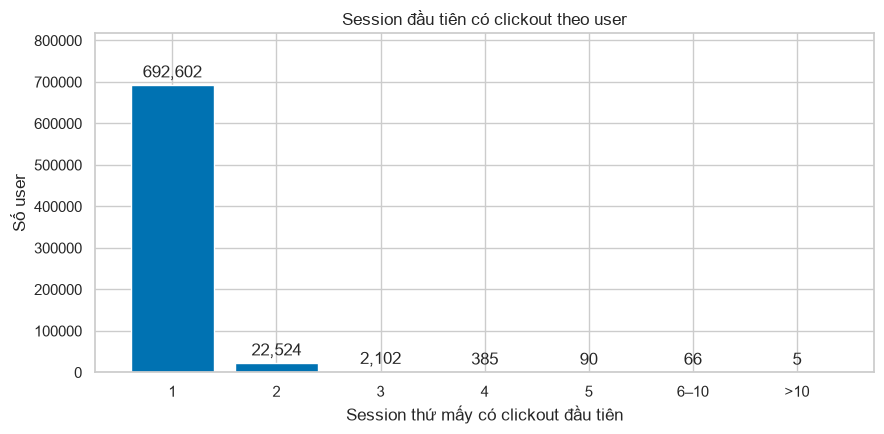

In [15]:
# Cell 14: Session clickout đầu tiên theo user
# Input/phạm vi: user train
# Output: bảng trạng thái và đồ thị
ordered=session_click_summary.loc[session_click_summary.session_start_timestamp.notna()].sort_values(['user_id','session_start_timestamp','session_id'],kind='stable').copy(); ordered['session_index']=ordered.groupby('user_id').cumcount()+1
first=ordered.loc[ordered.has_clickout].groupby('user_id',as_index=False).session_index.min().rename(columns={'session_index':'first_click_session_index'})
all_users=pd.Index(session_click_summary.user_id.dropna().unique(),name='user_id'); unordered=set(session_click_summary.loc[session_click_summary.has_clickout & session_click_summary.session_start_timestamp.isna(),'user_id'])
user_first_click_session=pd.DataFrame({'user_id':all_users}).merge(first,on='user_id',how='left')
user_first_click_session['status']=np.select([user_first_click_session.first_click_session_index.notna(),user_first_click_session.user_id.isin(unordered)],['Có clickout xếp theo thời gian','Có clickout nhưng thiếu timestamp'],'Chưa có clickout trong cửa sổ')
summary=user_first_click_session.groupby('status',as_index=False).size().rename(columns={'status':'Trạng thái','size':'Số user'}); summary['Tỷ lệ user (%)']=summary['Số user']/len(user_first_click_session)
display(summary.assign(**{'Tỷ lệ user (%)':summary['Tỷ lệ user (%)'].map(lambda x:f'{x:.2%}')}))
observed=user_first_click_session.first_click_session_index.dropna()
if len(observed):
 groups=pd.cut(observed,[.5,1.5,2.5,3.5,4.5,5.5,10.5,np.inf],labels=['1','2','3','4','5','6–10','>10']); counts=groups.value_counts(sort=False)
 fig,ax=plt.subplots(figsize=(9,4.5)); bars=ax.bar(counts.index.astype(str),counts.values,color=COLORS['primary']); ax.bar_label(bars,labels=[f'{x:,}' for x in counts.values],padding=3); ax.set(title='Session đầu tiên có clickout theo user',xlabel='Session thứ mấy có clickout đầu tiên',ylabel='Số user'); ax.margins(y=.18); plt.tight_layout(); plt.show()


**Nhận định.** User chưa click không phải phản hồi tiêu cực.

## 15. Metadata/provenance

Kiểm tra số dòng, ID trùng, missing properties, hash.

In [16]:
# Cell 15: Metadata và provenance
# Input/phạm vi: metadata/submission theo chunk
# Output: inventory/chẩn đoán
# Quét metadata theo chunk, đếm thiếu, ID item và property.
meta_null=Counter()
metadata_rows=0
metadata_item_properties=defaultdict(set)
for df in pd.read_csv(RAW/'item_metadata.csv',chunksize=CHUNKSIZE,dtype=str,keep_default_na=True,low_memory=False):
    metadata_rows+=len(df)
    for c in df.columns: meta_null[c]+=int(df[c].isna().sum())
    ids=df['item_id'].map(clean_id)
    for item,prop in zip(ids,df['properties'].array):
        if item is None: continue
        metadata_seen_counts[item] += 1
        metadata_items.add(item)
        props = split_pipe(prop) or []
        metadata_item_properties[item].update(value.strip() for value in props if value.strip())
metadata_item_property_counts = Counter({item: len(props) for item, props in metadata_item_properties.items()})
metadata_props = Counter(property_name for props in metadata_item_properties.values() for property_name in props)
submission_rows = sum(len(frame) for frame in pd.read_csv(RAW / 'submission_popular.csv', chunksize=CHUNKSIZE, dtype=str))
row_count_by_file = {'train.csv': row_counts['train.csv'], 'test.csv': row_counts['test.csv'], 'item_metadata.csv': metadata_rows, 'submission_popular.csv': submission_rows}
for record in inventory_records:
    record['row_count'] = row_count_by_file[Path(record['file']).name]
    record['scope'] = 'đếm full-data theo chunk; header không tính vào row_count'
inventory_table = pd.DataFrame(inventory_records)
display(inventory_table)
print('Số dòng metadata:', f'{metadata_rows:,}', '| số item ID duy nhất:', f'{len(metadata_items):,}', '| số dòng item_id trùng:', f'{sum(v - 1 for v in metadata_seen_counts.values()):,}')
# So khớp item trong log với metadata để tính coverage.


,file,exists,bytes,modified_utc,header,sha256_before_scan,row_count,scope
0,D:\VSF\Data\Tourism\Trivago_RecSys_Challenge_2...,True,2100807496,2019-10-25T15:43:02+00:00,"user_id,session_id,timestamp,step,action_type,...",285f07abbc87ea22e608ce194ece7bcc1047926339e269...,15932992,đếm full-data theo chunk; header không tính và...
1,D:\VSF\Data\Tourism\Trivago_RecSys_Challenge_2...,True,534912813,2019-10-25T15:43:02+00:00,"user_id,session_id,timestamp,step,action_type,...",f5917f91b3e83910f076e94804b86acf5ef56b2af482db...,3782335,đếm full-data theo chunk; header không tính và...
2,D:\VSF\Data\Tourism\Trivago_RecSys_Challenge_2...,True,257901183,2019-10-25T15:43:02+00:00,"item_id,properties",b1757ea4eded7475c84763391ef8cff00ba707590886b6...,927142,đếm full-data theo chunk; header không tính và...
3,D:\VSF\Data\Tourism\Trivago_RecSys_Challenge_2...,True,53035911,2019-10-25T15:43:02+00:00,"user_id,session_id,timestamp,step,item_recomme...",acaf3b3583308357b5d6e842c9de2473409f79f8ff8871...,253573,đếm full-data theo chunk; header không tính và...


Số dòng metadata: 927,142 | số item ID duy nhất: 927,142 | số dòng item_id trùng: 0


## 16. Coverage/property

Item thiếu metadata không đồng nghĩa 0 property.

,Khách sạn quan sát được,Có metadata,Không có dòng metadata,Độ phủ metadata (%)
0,905291,904436,855,99.91%


,Số item metadata,Item có property,Trung vị property/item,P90,P95,P99,Lớn nhất
0,927142,927142,15.0,46.0,55.0,71.0,112


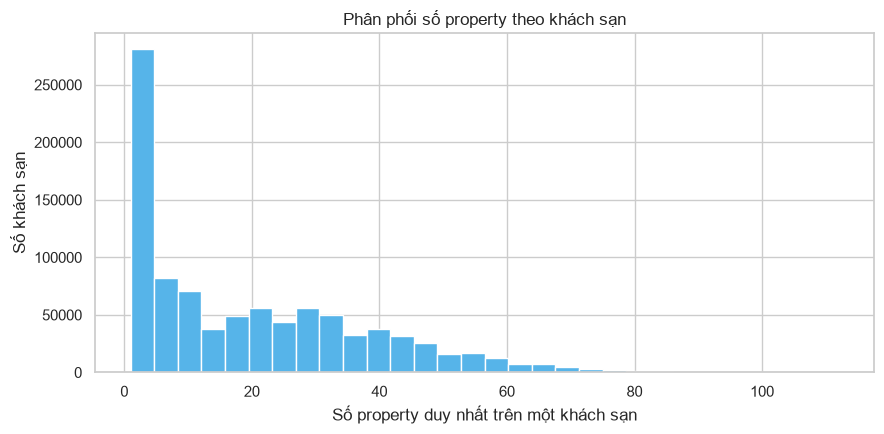

In [17]:
# Cell 16: Coverage metadata
# Input/phạm vi: item quan sát đối chiếu metadata
# Output: coverage/property và đồ thị
item_universe=set(candidate_item_ids)|set(train_item_universe); matched_items=item_universe & metadata_items
display(pd.DataFrame([{'Khách sạn quan sát được':len(item_universe),'Có metadata':len(matched_items),'Không có dòng metadata':len(item_universe-matched_items),'Độ phủ metadata (%)':f'{len(matched_items)/len(item_universe):.2%}' if item_universe else '—'}]))
property_counts=pd.Series(list(metadata_item_property_counts.values()),dtype='int64')
display(pd.DataFrame([{'Số item metadata':len(property_counts),'Item có property':int(property_counts.gt(0).sum()),'Trung vị property/item':property_counts.median() if len(property_counts) else np.nan,'P90':property_counts.quantile(.9) if len(property_counts) else np.nan,'P95':property_counts.quantile(.95) if len(property_counts) else np.nan,'P99':property_counts.quantile(.99) if len(property_counts) else np.nan,'Lớn nhất':property_counts.max() if len(property_counts) else np.nan}]))
if len(property_counts):
 fig,ax=plt.subplots(figsize=(9,4.5)); ax.hist(property_counts,bins=30,color=COLORS['secondary']); ax.set(title='Phân phối số property theo khách sạn',xlabel='Số property duy nhất trên một khách sạn',ylabel='Số khách sạn'); plt.tight_layout(); plt.show()


**Nhận định.** Coverage dùng item quan sát làm mẫu số; property chỉ xét item có dòng metadata.

## 17. Metadata/clickout

Gom khách sạn theo số property metadata duy nhất. Tỷ lệ click được tính bằng số candidate được chọn chia số lượt candidate hiển thị trong clickout train hợp lệ; metadata thiếu được tách thành một nhóm.


Tổng item trong bảng item-level: 853,542
Item có metadata: 852,744 | item thiếu metadata: 798


,property_bin,item_count,candidate_exposure_count,all_candidate_exposure_count,clicked_in_candidate_count,all_clickout_count,unique_click_sessions,observed_label_rate,rate_denominator_exposures
0,11–20,124787,2757834,2759098,108623,108677,94169,0.039387,2757834
1,1–5,278835,4060018,4062064,156176,156295,135993,0.038467,4060018
2,21–40,240378,11300503,11305705,476300,476526,410034,0.042149,11300503
3,6–10,73531,1210500,1211065,45907,45919,39504,0.037924,1210500
4,>40,135213,17018201,17026547,798188,798526,674668,0.046902,17018201
5,Thiếu metadata,798,13955,13957,643,643,541,0.046077,13955


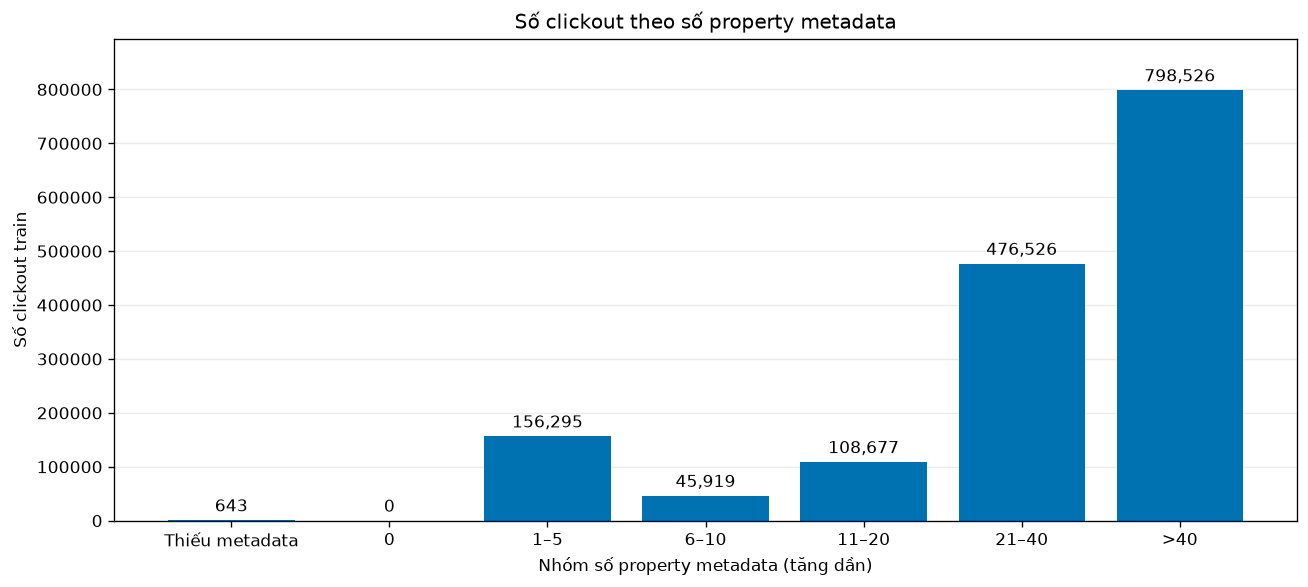

In [18]:
# Cell 17: Metadata và clickout
# Input/phạm vi: item-level train; metadata thiếu riêng
# Output: bảng và đồ thị tỷ lệ
# Cell: Bảng item-level nối metadata, clickout và candidate exposure

unique_click_sessions_by_item = Counter(item_id for _, item_id in positive_session_item)
item_rows = []
for item_id in train_item_universe:
    property_count = metadata_item_property_counts.get(item_id, np.nan)
    item_rows.append({
        'item_id': item_id,
        'metadata_property_count': property_count,
        'has_metadata': item_id in metadata_items,
        'all_clickout_count': train_clickout_by_item.get(item_id, 0),
        'unique_click_sessions': unique_click_sessions_by_item.get(item_id, 0),
        'candidate_exposure_count': train_candidate_exposure.get(item_id, 0),
        'all_candidate_exposure_count': train_all_candidate_exposure.get(item_id, 0),
        'clicked_in_candidate_count': train_clicked_candidate_by_item.get(item_id, 0),
    })
item_click_relation = pd.DataFrame(item_rows)
if not item_click_relation.empty:
    item_click_relation['observed_label_rate'] = (
        item_click_relation['clicked_in_candidate_count']
        / item_click_relation['candidate_exposure_count'].replace(0, np.nan)
    )
    property_bins = [-0.5, 0.5, 5.5, 10.5, 20.5, 40.5, np.inf]
    property_labels = ['0', '1–5', '6–10', '11–20', '21–40', '>40']
    item_click_relation['property_bin'] = pd.cut(
        item_click_relation['metadata_property_count'],
        bins=property_bins,
        labels=property_labels,
    ).astype('object')
    item_click_relation.loc[~item_click_relation['has_metadata'], 'property_bin'] = 'Thiếu metadata'
    property_order = ['Thiếu metadata', '0', '1–5', '6–10', '11–20', '21–40', '>40']
    item_click_relation['property_bin'] = pd.Categorical(item_click_relation['property_bin'], categories=property_order, ordered=True)
    property_bin_summary = (
        item_click_relation.groupby('property_bin', dropna=False, observed=False)
        .agg(
            item_count=('item_id', 'size'),
            candidate_exposure_count=('candidate_exposure_count', 'sum'),
            all_candidate_exposure_count=('all_candidate_exposure_count', 'sum'),
            clicked_in_candidate_count=('clicked_in_candidate_count', 'sum'),
            all_clickout_count=('all_clickout_count', 'sum'),
            unique_click_sessions=('unique_click_sessions', 'sum'),
        )
        .reset_index()
    )
    property_bin_summary['observed_label_rate'] = (
        property_bin_summary['clicked_in_candidate_count']
        / property_bin_summary['candidate_exposure_count'].replace(0, np.nan)
    )
    property_bin_summary['rate_denominator_exposures'] = property_bin_summary['candidate_exposure_count']
else:
    property_bin_summary = pd.DataFrame([{'status':'not_applicable','reason':'Không có item train quan sát để nối với metadata'}])
print('Tổng item trong bảng item-level:', f'{len(item_click_relation):,}')
print('Item có metadata:', f'{int(item_click_relation["has_metadata"].sum()):,}', '| item thiếu metadata:', f'{int((~item_click_relation["has_metadata"]).sum()):,}')
display(property_bin_summary)
# So sánh số clickout theo nhóm metadata; nhóm x tăng dần theo số property.
plot_bins = property_bin_summary.copy()
plot_order = ['Thiếu metadata', '0', '1–5', '6–10', '11–20', '21–40', '>40']
plot_bins['property_bin'] = pd.Categorical(plot_bins['property_bin'].astype(str), categories=plot_order, ordered=True)
plot_bins = plot_bins.sort_values('property_bin')
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(plot_bins['property_bin'].astype(str), plot_bins['all_clickout_count'], color=COLORS['primary'])
ax.bar_label(bars, labels=[f'{value:,.0f}' for value in plot_bins['all_clickout_count']], padding=3)
ax.set_ylim(0, max(float(plot_bins['all_clickout_count'].max()), 1) * 1.12)
ax.set(title='Số clickout theo số property metadata', xlabel='Nhóm số property metadata (tăng dần)', ylabel='Số clickout train')
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


**Nhận định.** Mỗi cột biểu diễn số candidate được chọn chia số lượt candidate đã hiển thị trong nhóm property tương ứng; nhóm metadata thiếu được tách riêng. Tỷ lệ này mô tả lựa chọn quan sát được trong train, không chứng minh metadata làm tăng khả năng được click.


## 18. Kết luận

Tổng hợp số liệu còn lại và xác nhận hash nguồn.

In [19]:
# Cell 18: Kết luận và hash
# Input/phạm vi: kết quả còn giữ; raw SHA-256
# Output: nhận định và hash
labeled_parseable=clicked_in_list+clicked_out_of_list; candidate_hit_rate=clicked_in_list/labeled_parseable if labeled_parseable else np.nan; metadata_coverage_rate=len(matched_items)/len(item_universe) if item_universe else np.nan
display(Markdown(f'''### Kết luận

Train có **{row_counts['train.csv']:,} event**. Trong **{labeled_parseable:,} clickout train** có nhãn và candidate hợp lệ, reference nằm trong impressions ở **{clicked_in_list:,} query ({candidate_hit_rate:.2%})**. Tỷ lệ candidate được chọn là **{selected_rate:.2%}** trên **{shown_candidates:,} candidate đã hiển thị**. Metadata có độ phủ **{metadata_coverage_rate:.2%}** trên **{len(item_universe):,} khách sạn quan sát được**.

Clickout ghi nhận hành động click, không xác nhận booking hay hài lòng.'''))
raw_hash_after={name:sha256_file(RAW/name) for name in FILES}; hash_check=pd.DataFrame([{'file':name,'sha256_before':raw_hash_before[name],'sha256_after':raw_hash_after[name],'unchanged':raw_hash_before[name]==raw_hash_after[name]} for name in FILES]); display(hash_check); assert hash_check.unchanged.all()


### Kết luận

Train có **15,932,992 event**. Trong **1,586,586 clickout train** có nhãn và candidate hợp lệ, reference nằm trong impressions ở **1,585,837 query (99.95%)**. Tỷ lệ candidate được chọn là **4.36%** trên **36,361,011 candidate đã hiển thị**. Metadata có độ phủ **99.91%** trên **905,291 khách sạn quan sát được**.

Clickout ghi nhận hành động click, không xác nhận booking hay hài lòng.

,file,sha256_before,sha256_after,unchanged
0,train.csv,285f07abbc87ea22e608ce194ece7bcc1047926339e269...,285f07abbc87ea22e608ce194ece7bcc1047926339e269...,True
1,test.csv,f5917f91b3e83910f076e94804b86acf5ef56b2af482db...,f5917f91b3e83910f076e94804b86acf5ef56b2af482db...,True
2,item_metadata.csv,b1757ea4eded7475c84763391ef8cff00ba707590886b6...,b1757ea4eded7475c84763391ef8cff00ba707590886b6...,True
3,submission_popular.csv,acaf3b3583308357b5d6e842c9de2473409f79f8ff8871...,acaf3b3583308357b5d6e842c9de2473409f79f8ff8871...,True


**Nhận định.** Clickout chỉ xác nhận click quan sát được, không xác nhận booking/hài lòng. Hash trước/sau kiểm tra nguồn không đổi.